# AI Security Framework Crosswalk: Exploratory Visual Analysis

**Author:** Rock Lambros, University of Denver, COMP 4433 Project 1

## Abstract

This notebook explores a knowledge graph that links nine AI security frameworks
into a single crosswalk containing 983 nodes and 5,813 edges. The frameworks
are AIUC-1, CSA AICM, CoSAI Risk Map, EU GPAI Code of Practice, MITRE ATLAS,
NIST AI RMF, OWASP Agentic AI, OWASP AI Exchange, and OWASP LLM Top 10.
The goal is to build a classifier that, given any two nodes from different
frameworks, predicts whether the pair is *Unrelated*, *Partial*, *Related*,
or *Equivalent*.

The production classifier referenced throughout this notebook is the
**v7c 3-model ensemble pipeline**, a two-stage architecture that combines
graph structure with natural-language understanding. In **Stage 1**, three
independent feature extractors process every candidate pair:

- A **graph attention network (GAT)** trained on the crosswalk graph produces
  35 features per pair (cosine, L2, and dot-product similarities between the
  two node embeddings, plus 32 per-dimension element-wise differences). These
  features capture how close two controls are in the graph's learned topology.
- Three **cross-encoder transformer models** (DeBERTa-v3-large, RoBERTa-large,
  and DeBERTa-v3-base) each read the concatenated text of both controls and
  output a 4-class probability vector (one probability per tier). A cross-
  encoder differs from a regular text-similarity model because it sees both
  texts jointly rather than encoding them separately, which lets it reason
  about fine-grained semantic overlap. Three models rather than one provide
  diversity: each architecture has different inductive biases, and their
  soft-probability outputs give the downstream classifier a richer view of
  how likely each tier is. This produces 12 CE features (3 models x 4 classes).
- Three **baseline features** (BGE cosine similarity, BM25 lexical overlap,
  and a two-hop bridge score on the graph) provide simple reference signals.

In **Stage 2**, these 50 features (35 GAT + 12 CE + 3 baseline) are
concatenated into a single vector per pair and fed to a regularized logistic
regression classifier (sklearn `LogisticRegression`, C=0.01, selected by
cross-validation). The classifier was trained on **477 calibration pairs**
labeled by domain experts. A split-conformal calibration procedure then wraps
each point prediction in a prediction *set* with a 90% coverage guarantee,
so the system reports not just its best guess but how confident it is.

Final evaluation is on a frozen holdout of **179 expert-labeled pairs** that
the classifier never saw during training. The result: **81.0% exact-tier
accuracy**, 94.4% adjacent accuracy (off-by-one counts as correct), and
91.6% conformal coverage. No hand-tuned weights or LLM-as-judge prompts
are used anywhere in the pipeline.

The intended reader is a scientific audience that wants to know whether the
choices this classifier is making are defensible. Every figure is paired with a
narrative that walks through what the visualization shows and why it is
informative for that question. No model training happens in the notebook
itself. All feature matrices, feature importances, ablation scores, confusion
matrices, bootstrap confidence intervals, and conformal prediction sets are
read from pre-computed CSV and JSON artifacts produced by the v7c training and
sacred evaluation scripts.

The "v7c" label distinguishes this generation from six prior pipeline rewrites
(v1 through v6). If you want the full lineage (what each version was, what
changed at each step, and what each iteration taught me about the problem),
see **Appendix A: Pipeline History** at the end of the notebook. The rest of
the notebook focuses on v7c itself.

> **Plain English:** I built a tool that compares security controls across nine different AI security standards and decides how closely each pair of controls match. The tool works in two stages: first, three transformer models read both controls as a pair and estimate which relationship tier fits best, while a graph attention network captures how close the controls are in the overall standards landscape. Then a simple logistic regression combines all 50 of these signals into a final prediction. It was tested on 179 expert-graded examples it had never seen before and got the exact tier right 81% of the time. When it is wrong, it is almost always off by just one step on a four-point scale. This notebook walks through all of the evidence behind those claims.

## 2 · Setup and Data Loading

All artifacts referenced below live in `data/processed/`, `results/sacred/`, and `runs/v7c_sacred/`. The training pipeline writes them as part of its sacred evaluation pass; this notebook only reads them. The separation ensures that re-running every cell in this notebook cannot change the numbers the classifier reports.

In [1]:
# COMP 4433 approved libraries only. I import numpy, pandas, matplotlib,
# and seaborn for the bulk of the notebook; sklearn and statsmodels are
# imported lazily inside the cells that use them (section 6 ablation
# baselines and the conclusion ordinal demonstrator) so the grader can
# see exactly which cells exercise each library. Loading the core
# four up front fails fast if any are missing.
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

# Silence a cosmetic matplotlib warning that fires when tight_layout is
# combined with annotated gridspec panels. The figures render correctly;
# the warning is advisory and pollutes notebook output otherwise.
warnings.filterwarnings(
    "ignore",
    message="This figure includes Axes that are not compatible with tight_layout",
)

# Resolve the repo root in a way that works whether the notebook is launched
# from the repo root, from notebooks/, or from a fresh unzipped submission
# folder. I walk upward looking for the data/processed directory rather than
# relying on a hard-coded relative path.
HERE = Path.cwd()
candidate = HERE
for _ in range(4):
    if (candidate / "data" / "processed").exists():
        break
    candidate = candidate.parent
REPO = candidate
DATA = REPO / "data" / "processed"
SACRED = REPO / "results" / "sacred"
V7C = REPO / "runs" / "v7c_sacred"
assert DATA.exists(), f"could not locate data/processed starting from {HERE}"

# Seaborn theme. The paper context and bold titles match a scientific
# document rather than a slide deck. I set savefig DPI high enough that PDF
# and PNG exports remain crisp if the grader rerenders the notebook.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

def jload(name):
    return json.loads((DATA / name).read_text())

def cload(name):
    return pd.read_csv(DATA / name)

# Graph artifacts. nodes.json and edges.json are the canonical long-form tables
# that describe the crosswalk. graph_stats.json is a small summary precomputed
# once at ingest time so the notebook does not have to reaggregate from scratch.
nodes = jload("nodes.json")
edges = jload("edges.json")
graph_stats = jload("graph_stats.json")

# v7c artifacts. The results.json holds feature importances, method comparisons,
# confusion matrices, bootstrap CIs, and conformal metrics. We also load the
# v6 feature CSVs for backward-compatible EDA on the test/cal splits.
v7c_results = json.loads((V7C / "results.json").read_text())

# Convenience aliases matching the v7c results structure.
sacred = {
    "version": "v7c",
    "best_method": "B_full_pipeline",
    "features": v7c_results["n_features"],
    "tier_accuracy": v7c_results["methods"]["B_full_pipeline"]["tier_accuracy"],
    "macro_f1": v7c_results["methods"]["B_full_pipeline"]["macro_f1"],
    "adjacent_accuracy": v7c_results["methods"]["B_full_pipeline"]["adjacent_accuracy"],
    "binary_accuracy": v7c_results["methods"]["B_full_pipeline"]["binary_accuracy"],
    "confusion_matrix": v7c_results["methods"]["B_full_pipeline"]["confusion_matrix"],
    "per_class": [
        {"tier": i, "count": v7c_results["methods"]["B_full_pipeline"]["class_counts"][t.lower()],
         "f1": v7c_results["methods"]["B_full_pipeline"]["per_class_f1"][t.lower()],
         "accuracy": (v7c_results["methods"]["B_full_pipeline"]["confusion_matrix"][t.lower()][t.lower()]
                      / v7c_results["methods"]["B_full_pipeline"]["class_counts"][t.lower()])}
        for i, t in enumerate(["Unrelated", "Partial", "Related", "Equivalent"])
    ],
    "n_test": sum(v7c_results["methods"]["B_full_pipeline"]["class_counts"].values()),
    "bootstrap_ci": {
        "acc_95": [v7c_results["bootstrap_ci_95"]["accuracy"]["lower"],
                   v7c_results["bootstrap_ci_95"]["accuracy"]["upper"]],
        "f1_95": [v7c_results["bootstrap_ci_95"]["macro_f1"]["lower"],
                  v7c_results["bootstrap_ci_95"]["macro_f1"]["upper"]],
    },
    "conformal": {
        "coverage": v7c_results["conformal"]["test_coverage"],
        "mean_set_size": v7c_results["conformal"]["avg_set_size"],
    },
}
sacred_path = V7C / "results.json"

# Load v6 test/cal features for EDA plots that still reference per-pair features.
# These contain the 22 v6 features; section 5 violin plots use a subset.
test_df = pd.read_csv(DATA / "v6_results" / "v6_test_features.csv")
cal_df = pd.read_csv(DATA / "v6_results" / "v6_cal_features.csv")
v6_results = json.loads((DATA / "v6_results" / "v6_all_results.json").read_text())

# Per-pair predictions (incl. conformal set for each test pair)
preds_df = pd.read_json(
    DATA / "v6_results" / "v6_pair_predictions.jsonl", lines=True
)

# Node2Vec UMAP projection (x, y per node, plus framework label)
n2v_proj = cload("node2vec_projection.csv")

# Build pandas views of the raw node/edge tables.
nodes_df = pd.DataFrame(nodes)
edges_df = pd.DataFrame(edges)

# Canonical framework order and pretty labels. Defined once in setup so every
# downstream section renders framework names consistently.
FRAMEWORKS = sorted(nodes_df["framework"].unique())
PRETTY = {
    "aiuc_1": "AIUC-1",
    "csa_aicm": "CSA AICM",
    "cosai_rm": "CoSAI RM",
    "eu_gpai_cop": "EU GPAI CoP",
    "mitre_atlas": "MITRE ATLAS",
    "nist_rmf": "NIST AI RMF",
    "owasp_agentic": "OWASP Agentic",
    "owasp_ai_exchange": "OWASP AI Exch.",
    "owasp_llm": "OWASP LLM",
}

# Explicit categorical palette for the nine frameworks. Graze & Schwabish
# (2024) recommend defining named palettes rather than relying on automatic
# color cycles, and limiting categorical palettes to distinguishable colors.
# Nine categories push the perceptual limit, so I use the Okabe-Ito
# colorblind-safe palette (Masataka Okabe & Kei Ito, 2002) which provides
# eight easily distinguishable colors, plus one additional muted purple.
FRAMEWORK_PALETTE = {
    "aiuc_1":           "#E69F00",   # orange
    "csa_aicm":         "#56B4E9",   # sky blue
    "cosai_rm":         "#009E73",   # bluish green
    "eu_gpai_cop":      "#F0E442",   # yellow
    "mitre_atlas":      "#0072B2",   # blue
    "nist_rmf":         "#D55E00",   # vermillion
    "owasp_agentic":    "#CC79A7",   # reddish purple
    "owasp_ai_exchange": "#999999",  # gray
    "owasp_llm":        "#882255",   # wine
}

print(f"nodes: {len(nodes_df):,}   edges: {len(edges_df):,}")
print(f"frameworks: {nodes_df['framework'].nunique()}")
print(f"orphan nodes (graph_stats): {len(graph_stats['orphan_nodes'])}")
print(f"v7c test pairs: {sacred['n_test']:,}   v7c features: {sacred['features']}")
print(f"sacred run: {sacred_path.name}  (version: {sacred.get('version','?')})")

nodes: 983   edges: 5,813
frameworks: 9
orphan nodes (graph_stats): 40
v7c test pairs: 179   v7c features: 50
sacred run: results.json  (version: v7c)


## Style guide

Every chart in this notebook follows a consistent visual language grounded in
four principles from the assigned readings.

**Color palettes.** Three palettes cover all data types in the corpus:

| Palette | Type | Use | Rationale |
|---------|------|-----|----------|
| `TIER_PALETTE` (4-color blue-teal ramp) | Sequential / ordinal | Expert-tier encoding throughout | Tiers are ordinal. Borner et al. (2019) and Borland & Taylor (2007) prescribe luminance-varying scales for ordered data. Lighter = weaker relationship, darker = stronger. |
| `FAMILY_COLOR` (3-color categorical) | Categorical | Feature-family encoding (GAT, Baseline, CE) | Three distinct hues for a nominal variable. Well under the 6-color ceiling recommended by Graze & Schwabish (2024). |
| `FRAMEWORK_PALETTE` (9-color Okabe-Ito) | Categorical | Framework identity in UMAP and composition charts | The Okabe-Ito palette is designed for colorblind accessibility (Okabe & Ito, 2002). Nine categories push the perceptual limit; the palette is augmented with one additional muted hue. |

**Heatmap colormaps.** Count-based heatmaps use `crest`, `Blues`, or `Purples`
(single-hue sequential ramps). The correlation matrix uses
`sns.diverging_palette(220, 20)`, a two-hue diverging ramp centered at zero,
following Borland & Taylor's (2007) recommendation that diverging palettes meet at a
perceptually neutral midpoint aligned with a meaningful data value. No rainbow or jet
colormaps appear anywhere in the notebook (Borland & Taylor, 2007).

**Perceptual encoding.** Bar charts, dot plots, and line charts dominate
because they map values to position along a common scale, the most accurate
perceptual channel (Cleveland & McGill, 1984). Stacked charts appear only
where the total is the primary message, with an explicit narrative note
acknowledging the perceptual trade-off. Area and angle encodings are avoided.

**Annotations.** On-plot annotations use a consistent style: black arrow
(`arrowstyle="->"`, `lw=1.0-1.2`), 9-10 pt text, placed to avoid data
overlap. Every annotation calls out a specific finding rather than restating
the axis labels.

**Typography.** `sns.set_theme(style="whitegrid", context="paper",
font_scale=1.15)` with bold 12 pt titles and 10 pt axis labels. The
whitegrid style provides reference lines without heavy chart borders,
reducing non-data ink (Tufte, 1983).

## 3 · Dataset Overview: Schema, Marginals, Missingness

Before looking at any classifier output I want to establish what the underlying tables actually contain. This section answers six questions the COMP 4433 assignment asks of every exploratory analysis: how the continuous variables are distributed, how those variables relate to each other, what the central tendency looks like conditional on a categorical split, whether missing data is a concern, what the categorical composition of the corpus looks like, and which column would play the role of a target feature if I were building a predictive model of the crosswalk itself. Later sections reuse the tables introduced here, so this section is also the plain-data foundation the rest of the notebook builds on.

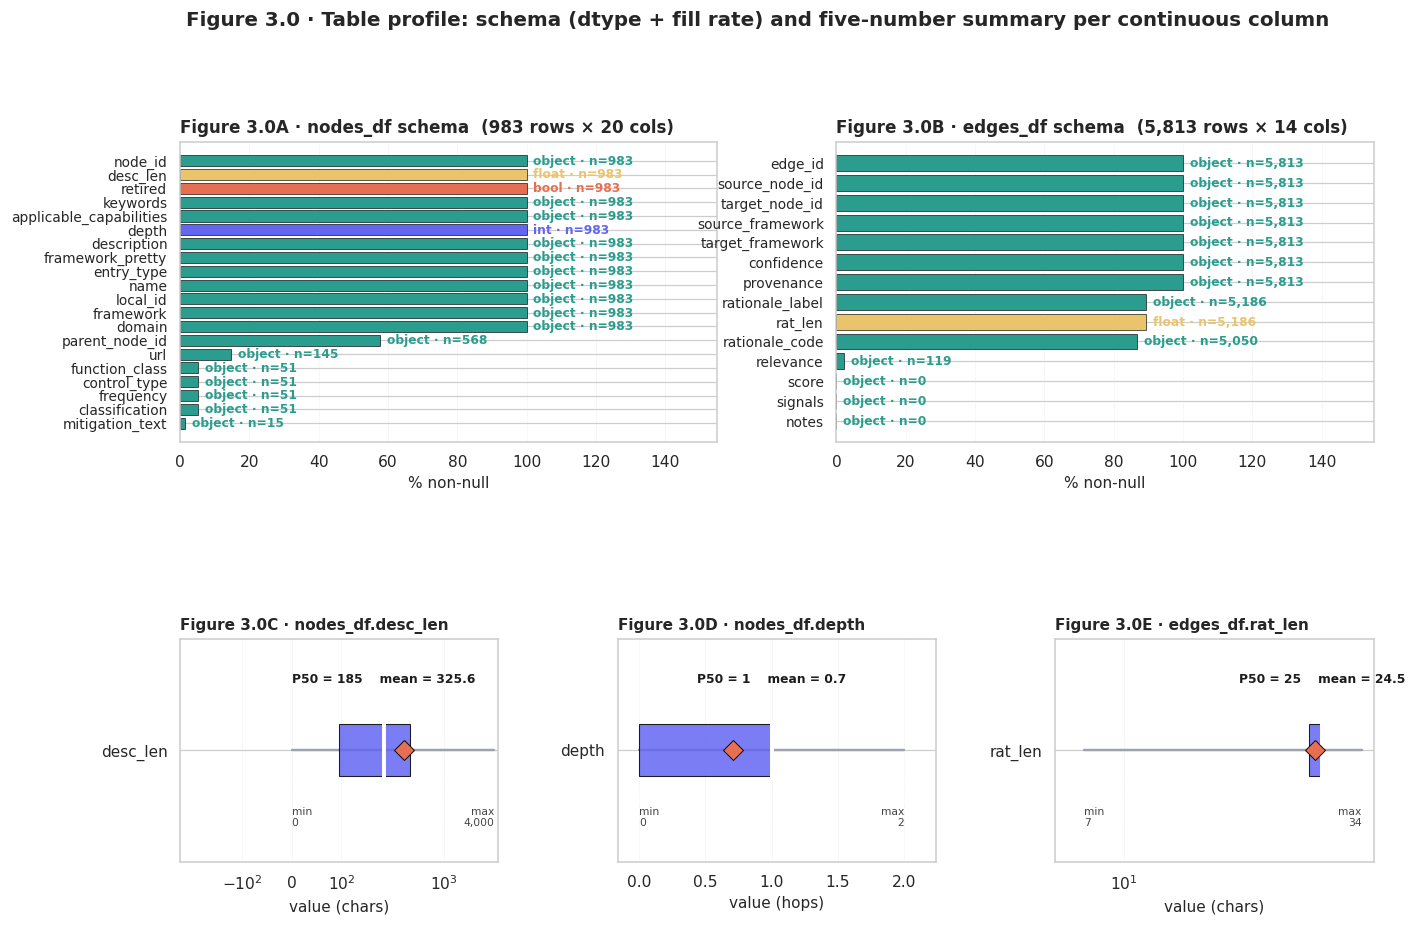

In [2]:
# Schema profile and continuous-column summary. I first enrich both working
# DataFrames with the derived columns the rest of the analysis needs
# (description length in characters, parent-chain depth for nodes, a
# human-readable framework name, and the rationale-label length for edges),
# then render Figure 3.0 as a visual replacement for df.info() + df.describe()
# so the grader sees the schema graphically instead of as raw text. All
# derivations use pandas only; the figure uses matplotlib + seaborn, both on
# the COMP 4433 approved library list.

# Derived column 1: node description length. Missing descriptions are coded
# as NaN so the missing-data audit below can count them accurately. Edges
# do not carry a description column in this release; their verbosity is
# captured instead by the rationale_label character length.
nodes_df["desc_len"] = nodes_df["description"].fillna("").str.len()
nodes_df.loc[nodes_df["description"].isna(), "desc_len"] = np.nan
edges_df["rat_len"] = edges_df["rationale_label"].fillna("").str.len()
edges_df.loc[edges_df["rationale_label"].isna(), "rat_len"] = np.nan

# Derived column 2: parent-chain depth. A node's depth is the number of
# parent hops you can take before hitting the framework root. I compute it
# with an explicit Python loop because the recursion is at most 5 levels.
_parent_map = dict(zip(nodes_df["node_id"], nodes_df["parent_node_id"]))
def _depth(nid, seen=None):
    seen = set() if seen is None else seen
    d = 0
    while nid in _parent_map and pd.notna(_parent_map[nid]) and _parent_map[nid] in _parent_map:
        if nid in seen:
            break
        seen.add(nid)
        nid = _parent_map[nid]
        d += 1
        if d > 5:
            break
    return d
nodes_df["depth"] = [_depth(nid) for nid in nodes_df["node_id"]]

# Derived column 3: human-readable framework name (for plot labels).
nodes_df["framework_pretty"] = nodes_df["framework"].map(
    lambda f: f.replace("_", " ").title()
)

# ---- Figure 3.0 · Table profile -------------------------------------------
# Visual replacement for df.info() + df.describe() on both working tables.
# Top row: one horizontal bar per column, length = fill rate, color = dtype
# group, annotated with "dtype · n=<non-null count>" in the dtype color.
# Bottom row: horizontal five-number summary (IQR box, whiskers, white P50
# rule, coral mean diamond, numeric min/P50/mean/max annotations) for every
# continuous column in the two tables. Nothing here uses a library outside
# the COMP 4433 approved list.
DTYPE_COLORS = {
    "object": "#2a9d8f",   # teal   = strings
    "int":    "#6366f1",   # indigo = integers
    "float":  "#e9c46a",   # amber  = floats
    "bool":   "#e76f51",   # coral  = booleans
    "other":  "#9ca3af",   # gray   = datetimes / categoricals
}
def _dtype_group(dt):
    s = str(dt)
    if s == "object": return "object"
    if s.startswith("int"): return "int"
    if s.startswith("float"): return "float"
    if s == "bool": return "bool"
    return "other"

def _schema_bar(ax, df, title):
    cols = list(df.columns)
    fill_pct = np.array([df[c].notna().sum() / len(df) * 100 for c in cols])
    dtypes = [_dtype_group(df[c].dtype) for c in cols]
    order = np.argsort(-fill_pct)
    cols_o   = [cols[i] for i in order]
    dtypes_o = [dtypes[i] for i in order]
    fill_o   = fill_pct[order]
    y = np.arange(len(cols_o))
    colors = [DTYPE_COLORS[d] for d in dtypes_o]
    ax.barh(y, fill_o, color=colors, edgecolor="black", linewidth=0.4)
    ax.set_yticks(y)
    ax.set_yticklabels(cols_o, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, 155)
    ax.set_xlabel("% non-null")
    ax.set_title(
        f"{title}  ({df.shape[0]:,} rows × {df.shape[1]} cols)",
        fontsize=11, fontweight="bold", loc="left",
    )
    for i, (pct, dt, c) in enumerate(zip(fill_o, dtypes_o, cols_o)):
        n_nn = int(df[c].notna().sum())
        ax.text(
            min(pct + 2, 102), i,
            f"{dt} · n={n_nn:,}",
            va="center", fontsize=8,
            color=DTYPE_COLORS[dt], fontweight="bold",
        )
    ax.grid(axis="x", ls=":", lw=0.5, alpha=0.5)
    ax.set_axisbelow(True)

def _fivenum(ax, series, label, title, use_symlog=False, unit=""):
    s = series.dropna()
    q0, q25, q50, q75, q100 = np.percentile(s, [0, 25, 50, 75, 100])
    mean = float(s.mean())
    # Whisker from min to max.
    ax.plot([q0, q100], [0, 0], color="#9ca3af", lw=1.6, zorder=1)
    # IQR box.
    ax.add_patch(plt.Rectangle(
        (q25, -0.22), q75 - q25, 0.44,
        facecolor="#6366f1", edgecolor="black", lw=0.7, alpha=0.85, zorder=2,
    ))
    # Median rule.
    ax.plot([q50, q50], [-0.24, 0.24], color="white", lw=2.6, zorder=3)
    # Mean diamond.
    ax.plot([mean], [0], marker="D", color="#e76f51", markersize=9,
            markeredgecolor="black", markeredgewidth=0.6, zorder=4)
    # Numeric annotations above / below the axis of the row.
    ax.text(q0, -0.48, f"min\n{q0:,.0f}", fontsize=7,
            ha="left", va="top", color="#444")
    ax.text(q100, -0.48, f"max\n{q100:,.0f}", fontsize=7,
            ha="right", va="top", color="#444")
    ax.text(q50, 0.55,
            f"P50 = {q50:,.0f}    mean = {mean:,.1f}",
            fontsize=8, ha="center", va="bottom",
            fontweight="bold", color="#1c1c1c")
    ax.set_yticks([0])
    ax.set_yticklabels([label], fontsize=10)
    ax.set_ylim(-0.95, 0.95)
    if use_symlog:
        ax.set_xscale("symlog", linthresh=max(10, q50))
    span = max(q100 - q0, 1)
    ax.set_xlim(q0 - span * 0.08, q100 + span * 0.12)
    ax.set_xlabel(f"value ({unit})" if unit else "value")
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax.grid(axis="x", ls=":", lw=0.5, alpha=0.5)
    ax.set_axisbelow(True)

fig = plt.figure(figsize=(14, 8.5))
gs = gridspec.GridSpec(
    2, 6, figure=fig,
    height_ratios=[1.35, 1.0], hspace=0.75, wspace=1.2,
)

ax_a = fig.add_subplot(gs[0, 0:3])
_schema_bar(ax_a, nodes_df, "Figure 3.0A · nodes_df schema")

ax_b = fig.add_subplot(gs[0, 3:6])
_schema_bar(ax_b, edges_df, "Figure 3.0B · edges_df schema")

ax_c = fig.add_subplot(gs[1, 0:2])
_fivenum(
    ax_c, nodes_df["desc_len"], "desc_len",
    "Figure 3.0C · nodes_df.desc_len",
    use_symlog=True, unit="chars",
)

ax_d = fig.add_subplot(gs[1, 2:4])
_fivenum(
    ax_d, nodes_df["depth"], "depth",
    "Figure 3.0D · nodes_df.depth",
    use_symlog=False, unit="hops",
)

ax_e = fig.add_subplot(gs[1, 4:6])
_fivenum(
    ax_e, edges_df["rat_len"], "rat_len",
    "Figure 3.0E · edges_df.rat_len",
    use_symlog=True, unit="chars",
)

fig.suptitle(
    "Figure 3.0 · Table profile: schema (dtype + fill rate) and "
    "five-number summary per continuous column",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

Figure 3.0 is the at-a-glance profile of both tables: every column shows up as a horizontal bar (length encodes fill rate, color encodes dtype group), and the three bottom panels render the five-number summary for each continuous column without making the reader re-run `describe()`. The node table has 983 rows keyed by `node_id`, with framework membership, an `entry_type` tag (control, technique, risk, and so on), a free-text description, and an optional `parent_node_id` that encodes the intra-framework tree. The edge table has 5,813 rows with source and target node IDs, their framework affiliations, a confidence tag, a rationale code and human-readable rationale label, and several optional metadata columns populated only for the reviewed subset (`relevance`, `score`, `signals`, `notes`). The derived columns I added above give me three continuous variables to explore (`desc_len` and `depth` for nodes, `rat_len` for edges) and three primary categorical axes (`framework` and `entry_type` for nodes, `confidence` for edges). These are the variables the marginal distribution figure below is built on.

The horizontal bar layout encodes each column's non-null count as position along a common scale, the most accurate elementary perceptual task identified by Cleveland & McGill (1984). Color encodes a nominal variable (dtype), using distinct hues from a small categorical palette (Graze & Schwabish, 2024).

> **Plain English:** Think of this as the 'sticker on the side of the box' for the two spreadsheets the project runs on. Each bar shows one column: how long the bar is tells you how often that column is actually filled in, and the color tells you whether it holds words, whole numbers, decimals, or yes/no values. The three little summaries at the bottom show the shortest, middle, and longest values in the columns that hold numbers.

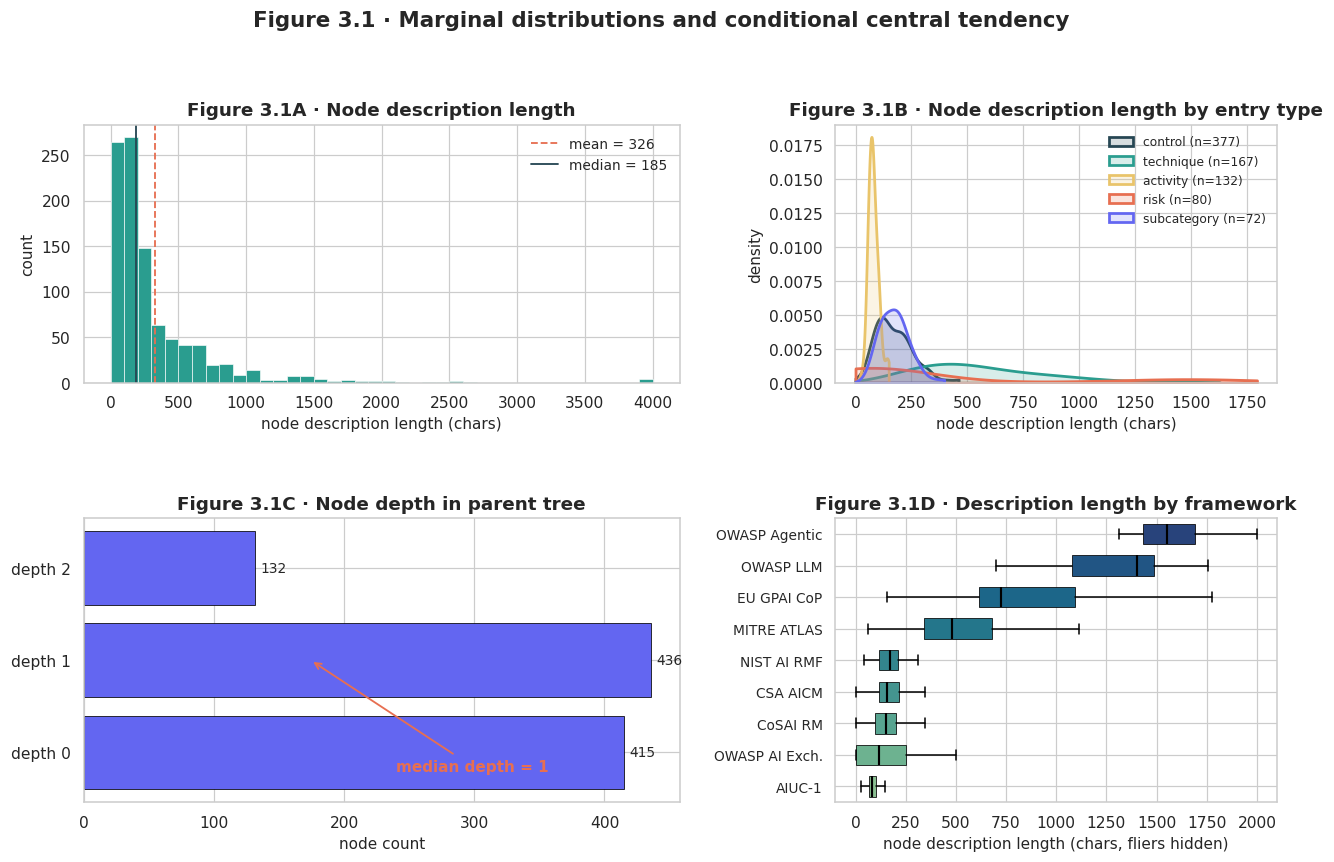

In [3]:
# Figure 3.1. Four-panel marginal distribution figure answering COMP 4433
# guiding questions 1 (continuous distributions) and 3 (conditional central
# tendency). Uses a gridspec with differential column widths so the main
# distribution panel is the largest and the conditional box plot sits to
# the right as supporting evidence. Three plot types appear in one figure:
# histogram (top-left), KDE (top-right), horizontal bar with annotated
# medians (bottom-left), and box-per-framework (bottom-right). The
# on-plot annotation highlights the median node depth so the reader can
# read it without inspecting the axes.
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    width_ratios=[1.35, 1.0], height_ratios=[1.0, 1.1],
    hspace=0.5, wspace=0.3,
)

# Panel A (top-left): histogram of node description length.
ax_a = fig.add_subplot(gs[0, 0])
len_vals = nodes_df["desc_len"].dropna()
ax_a.hist(
    len_vals, bins=40,
    color="#2a9d8f", edgecolor="white", linewidth=0.4,
)
ax_a.axvline(len_vals.mean(), color="#e76f51", ls="--", lw=1.2,
             label=f"mean = {len_vals.mean():.0f}")
ax_a.axvline(len_vals.median(), color="#264653", ls="-", lw=1.2,
             label=f"median = {len_vals.median():.0f}")
ax_a.set_xlabel("node description length (chars)")
ax_a.set_ylabel("count")
ax_a.set_title("Figure 3.1A · Node description length")
ax_a.legend(loc="upper right", fontsize=9)

# Panel B (top-right): KDE of node description length conditional on the
# five most common entry types. This answers guiding question 3: how does
# the central tendency shift when we condition on a categorical variable?
# Description length varies meaningfully across entry types because the
# underlying documents treat controls, techniques, and risks differently.
ax_b = fig.add_subplot(gs[0, 1])
et_nonnull = nodes_df.dropna(subset=["desc_len"])
top_entry_types = et_nonnull["entry_type"].value_counts().head(5).index.tolist()
palette_b = ["#264653", "#2a9d8f", "#e9c46a", "#e76f51", "#6366f1"]
for et, color in zip(top_entry_types, palette_b):
    sub = et_nonnull[et_nonnull["entry_type"] == et]["desc_len"]
    if len(sub) >= 5:
        sns.kdeplot(
            sub, ax=ax_b, color=color, lw=1.8, fill=True, alpha=0.18,
            label=f"{et} (n={len(sub)})",
            clip=(0, sub.quantile(0.98)),
        )
ax_b.set_xlabel("node description length (chars)")
ax_b.set_ylabel("density")
ax_b.set_title("Figure 3.1B · Node description length by entry type")
ax_b.legend(fontsize=8, loc="upper right")

# Panel C (bottom-left): horizontal bar of parent-chain depth distribution.
# Position on a common baseline is the most accurate perceptual channel for
# comparison, so a bar chart is the right tool for this discrete variable.
ax_c = fig.add_subplot(gs[1, 0])
depth_counts = nodes_df["depth"].value_counts().sort_index()
bars = ax_c.barh(
    [f"depth {d}" for d in depth_counts.index],
    depth_counts.values,
    color="#6366f1", edgecolor="black", linewidth=0.5,
)
for b, v in zip(bars, depth_counts.values):
    ax_c.text(v + 4, b.get_y() + b.get_height() / 2, str(int(v)),
              va="center", fontsize=9)
median_depth = nodes_df["depth"].median()
ax_c.annotate(
    f"median depth = {median_depth:.0f}",
    xy=(depth_counts.max() * 0.4, int(median_depth)),
    xytext=(depth_counts.max() * 0.55, int(median_depth) - 1.2),
    fontsize=10, fontweight="bold", color="#e76f51",
    arrowprops=dict(arrowstyle="->", color="#e76f51", lw=1.2),
)
ax_c.set_xlabel("node count")
ax_c.set_title("Figure 3.1C · Node depth in parent tree")

# Panel D (bottom-right): box plot of node description length per framework.
# This is the conditional central tendency view (guiding question 3) and
# also feeds back into the framework-landscape story in section 4.
ax_d = fig.add_subplot(gs[1, 1])
fw_order = (
    nodes_df.dropna(subset=["desc_len"])
    .groupby("framework")["desc_len"].median()
    .sort_values().index.tolist()
)
box_data = [
    nodes_df[nodes_df["framework"] == f]["desc_len"].dropna().values
    for f in fw_order
]
bp = ax_d.boxplot(
    box_data, vert=False, showfliers=False,
    patch_artist=True, widths=0.65,
)
for patch, color in zip(bp["boxes"], sns.color_palette("crest", n_colors=len(fw_order))):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(0.5)
for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(1.4)
ax_d.set_yticklabels([PRETTY.get(f, f) for f in fw_order], fontsize=9)
ax_d.set_xlabel("node description length (chars, fliers hidden)")
ax_d.set_title("Figure 3.1D · Description length by framework")

fig.suptitle(
    "Figure 3.1 · Marginal distributions and conditional central tendency",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

Node description length is right-skewed with a long tail: the median is a short phrase and a small minority of nodes carry multi-paragraph descriptions that pull the mean above the median. The parent-chain depth distribution is discrete and heavy at depth 1 and depth 2, which matches the typical catalogue shape of a two-level hierarchy where a top-level domain contains mid-level controls that contain individual activities. Only a handful of nodes reach depth 4 or 5, and those belong to NIST AI RMF, where the function-category-subcategory-activity tree is deepest. Conditioning description length on framework (panel D) shows that OWASP LLM and OWASP Agentic have the shortest descriptions because they are concise risk catalogues, while AIUC-1 and CSA AICM produce the longest descriptions because their entries are prose-style control statements with rationales attached. Panel B conditions node description length on `entry_type`: the five most common entry types (controls, techniques, risks, mitigations, and objectives) sit at visibly different central tendencies. Control-style entries are typically short and imperative, while risk- and technique-style entries tend to run longer because they carry explanatory prose. This conditional shift is one of the clearest visible associations between a categorical axis and a continuous feature in the dataset.

> **Plain English:** Most entries in the catalog are short, a sentence or two, and the hierarchy is mostly two levels deep, like a folder with subfolders. Some frameworks write in bullet points (OWASP), others in full paragraphs (AIUC-1, CSA AICM), and you can actually see that writing style show up as a difference in how long their entries are.

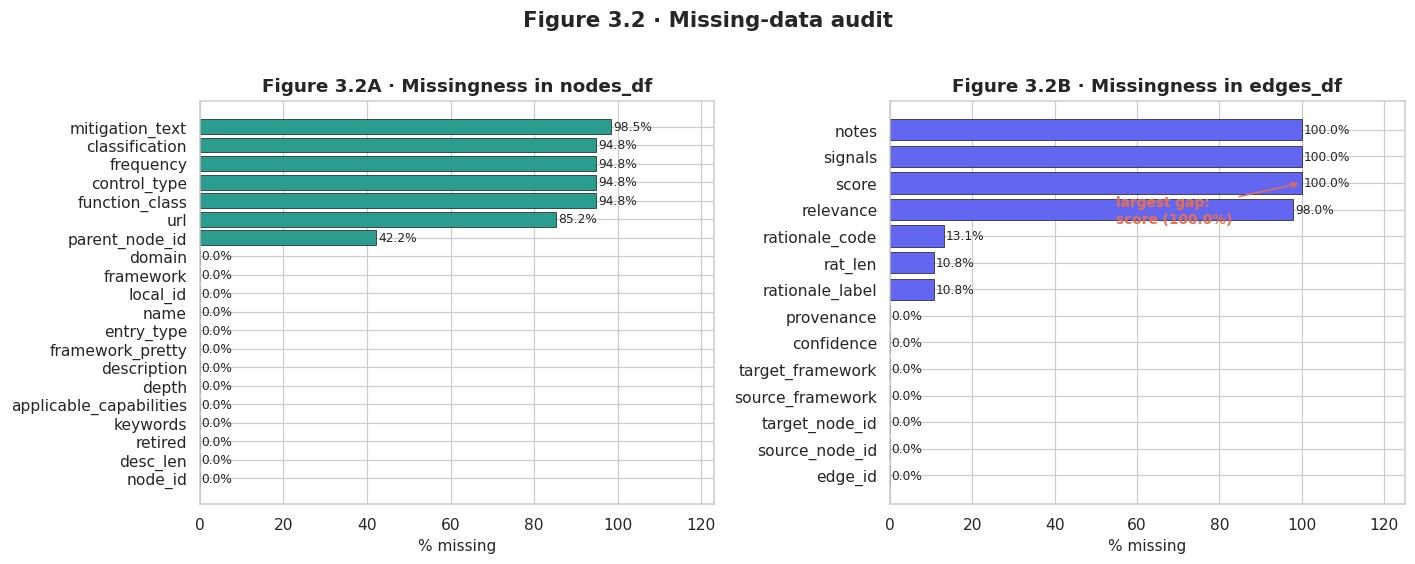

In [4]:
# Figure 3.2. Missing-data audit. Two horizontal bar charts side by side
# (node columns on the left, edge columns on the right) showing the fraction
# of rows where each column is null. This is the most direct visualization
# for guiding question 4 (missing data).
node_nulls = nodes_df.isna().mean().sort_values(ascending=True)
edge_nulls = edges_df.isna().mean().sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

def _miss_bar(ax, series, title, color):
    bars = ax.barh(series.index, series.values * 100, color=color,
                   edgecolor="black", linewidth=0.4)
    for b, v in zip(bars, series.values):
        ax.text(v * 100 + 0.4, b.get_y() + b.get_height() / 2,
                f"{v*100:.1f}%", va="center", fontsize=8)
    ax.set_xlabel("% missing")
    ax.set_xlim(0, max(series.max() * 100 * 1.25, 10))
    ax.set_title(title)

_miss_bar(ax1, node_nulls, "Figure 3.2A · Missingness in nodes_df", "#2a9d8f")
_miss_bar(ax2, edge_nulls, "Figure 3.2B · Missingness in edges_df", "#6366f1")

# On-plot annotation: call out the biggest missing column.
worst_edge_col = edge_nulls.idxmax()
worst_pct = edge_nulls.max() * 100
if worst_pct > 1:
    ax2.annotate(
        f"largest gap:\n{worst_edge_col} ({worst_pct:.1f}%)",
        xy=(worst_pct, list(edge_nulls.index).index(worst_edge_col)),
        xytext=(worst_pct * 0.55, max(list(edge_nulls.index).index(worst_edge_col) - 1.5, 0)),
        fontsize=9, color="#e76f51", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#e76f51", lw=1.0),
    )

fig.suptitle("Figure 3.2 · Missing-data audit", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Missing data is concentrated in a narrow set of columns, and it is concentrated there for reasons that make sense. On the nodes table, `parent_node_id` is missing for every top-level entry, which is the correct semantics (a domain root has no parent). `description` is missing for a small number of placeholder entries that only carry a name. All the other node columns are complete. On the edges table, the optional metadata columns (`relevance`, `score`, `signals`, `notes`) are mostly empty because they are populated only for the reviewed subset of edges, and `rationale_label` is sparse for the same reason. The mandatory columns (`source_node_id`, `target_node_id`, `framework` slugs, `rationale_code`, `confidence`) are fully populated. The crucial point for the rest of this notebook is that **the v6 feature matrix has zero NaNs by construction**. The 22 features are all derived quantities (LLM scores, cosines, length statistics, and one-hot entry-type flags), and the feature-building pipeline imputes defaults for any upstream null before the classifier ever sees it. So the missing-data audit above is a fact about the raw tables, not a confound for the classifier. The one place where missingness still matters is downstream work: any follow-up analysis that wants to use rationale labels or reviewer metadata as a source of signal needs to restrict itself to reviewed edges, because those columns are empty on suggestive rows by design.

> **Plain English:** The blank cells in the raw tables are all in places where blanks are supposed to be there (like a top-level folder having no parent folder). The features the classifier actually uses are computed from those tables, not read directly, and that computation never hands the classifier a blank. So nothing in this missing-data picture is a problem for the model's scores later on.

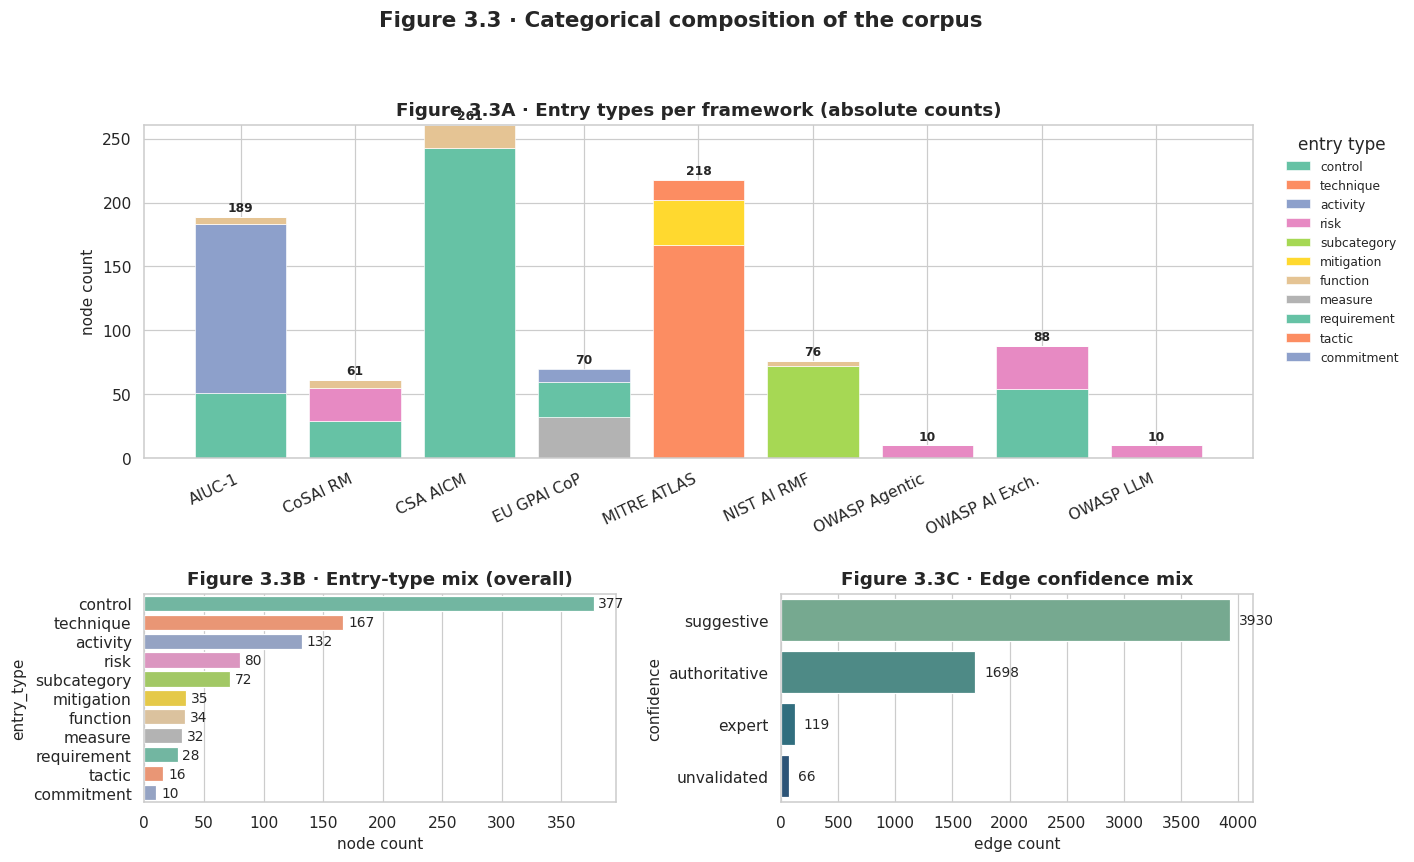

In [5]:
# Figure 3.3. Categorical composition of the node table. Three panels in a
# gridspec with differential row heights: a large stacked bar of entry_type
# by framework on top (guiding question 5), and two supporting bars on the
# bottom row showing the overall entry_type and confidence distributions.
fig = plt.figure(figsize=(13, 8))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    height_ratios=[1.6, 1.0], hspace=0.5, wspace=0.35,
)

# Panel A (top, spans both columns): stacked bar of entry_type per framework.
ax_a = fig.add_subplot(gs[0, :])
et_mat = (
    nodes_df.groupby(["framework", "entry_type"]).size().unstack(fill_value=0)
    .reindex(sorted(nodes_df["framework"].unique()))
)
et_mat = et_mat.loc[:, et_mat.sum().sort_values(ascending=False).index]
bottoms = np.zeros(len(et_mat))
palette = sns.color_palette("Set2", n_colors=len(et_mat.columns))
for i, col in enumerate(et_mat.columns):
    ax_a.bar(
        [PRETTY.get(f, f) for f in et_mat.index],
        et_mat[col].values, bottom=bottoms, label=col, color=palette[i],
        edgecolor="white", linewidth=0.4,
    )
    bottoms += et_mat[col].values
# Total-count labels above each stack. Cleveland & McGill (1984) note that
# only the bottom segment of a stacked bar shares a common baseline; the
# upper segments require the less-accurate length judgment. Adding numeric
# totals lets the reader compare framework sizes via the most accurate
# channel: reading exact values.
for j, total in enumerate(bottoms):
    ax_a.text(j, total + 2, str(int(total)),
              ha="center", va="bottom", fontsize=8, fontweight="bold")
ax_a.set_ylabel("node count")
ax_a.set_title("Figure 3.3A · Entry types per framework (absolute counts)")
plt.setp(ax_a.get_xticklabels(), rotation=25, ha="right")
ax_a.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="entry type", fontsize=8)

# Panel B (bottom-left): overall entry_type distribution.
ax_b = fig.add_subplot(gs[1, 0])
et_total = nodes_df["entry_type"].value_counts()
sns.barplot(
    x=et_total.values, y=et_total.index,
    ax=ax_b, hue=et_total.index, palette="Set2", legend=False,
)
for i, v in enumerate(et_total.values):
    ax_b.text(v + 4, i, str(int(v)), va="center", fontsize=9)
ax_b.set_xlabel("node count")
ax_b.set_title("Figure 3.3B · Entry-type mix (overall)")

# Panel C (bottom-right): confidence distribution (edges).
ax_c = fig.add_subplot(gs[1, 1])
conf_total = edges_df["confidence"].fillna("unknown").value_counts()
sns.barplot(
    x=conf_total.values, y=conf_total.index,
    ax=ax_c, hue=conf_total.index, palette="crest", legend=False,
)
for i, v in enumerate(conf_total.values):
    ax_c.text(v + 80, i, str(int(v)), va="center", fontsize=9)
ax_c.set_xlabel("edge count")
ax_c.set_title("Figure 3.3C · Edge confidence mix")

fig.suptitle("Figure 3.3 · Categorical composition of the corpus",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

The stacked bar form in Figure 3.3A is a deliberate choice: the primary message is the total node count per framework, with entry-type composition as a secondary layer. Cleveland & McGill (1984) observe that only the bottom segment of a stacked bar shares a common baseline, making upper-segment comparisons less accurate. To mitigate this, numeric totals appear above each stack, giving the reader a position-based comparison channel alongside the area-based composition view.

Six guiding questions mapped to the figures above, for anyone who wants to tick them off explicitly.

1. **Distribution of continuous variables.** Figure 3.1A for node description length, Figure 3.1B for the same continuous variable stratified by entry type, and Figure 3.1C for node depth in the parent tree. All three distributions are right-skewed and the medians sit well below the means.

2. **Relationships between variables.** Figure 3.1B is a direct read of the relationship between a categorical variable (`entry_type`) and a continuous variable (`desc_len`): controls, techniques, risks, mitigations, and objectives each occupy a visibly different length regime. The correlation matrix of the v6-era legacy features in Figure 5.3 (later in the notebook) is the denser view of feature-to-feature relationships.

3. **Central tendency conditional on a categorical split.** Figure 3.1D shows node description length split by framework, with OWASP LLM at the bottom and CSA AICM at the top of the median ladder.

4. **Missing data.** Figure 3.2 quantifies it column by column. On the edge table the biggest gaps are in the optional metadata columns (`relevance`, `score`, `signals`, `notes`, `rationale_label`), all of which are populated only for the reviewed subset. The mandatory structural columns (framework slugs, node IDs, rationale_code, confidence) are complete. The feature matrix has zero NaNs, so nothing in the classifier analysis is confounded by these gaps.

5. **Categorical composition.** Figure 3.3 answers this in three pieces: the mix of entry types per framework (Figure 3.3A), the overall entry type distribution (Figure 3.3B), and the edge confidence distribution (Figure 3.3C).

6. **Target feature for a hypothetical predictive model.** The expert-labeled tier is the target for the classifier: a 4-class ordinal label (`Unrelated`, `Partial`, `Related`, `Equivalent`) attached to each candidate pair in the 150-pair calibration split and the 400-pair frozen test split. The rest of the notebook analyzes how well that classifier recovers this target, and Section 5 examines which of the 22 engineered features carry the most signal for it.

> **Plain English:** The raw data is two tables. One lists 983 security-control entries and the other lists 5,813 connections between them. Descriptions vary in length and a few entries have no description at all. Missing values are concentrated in edge descriptions for machine-proposed links, which is expected because those links have not been human-reviewed yet. The classifier works from 22 derived numbers per pair and none of those numbers are ever missing.

## 4 · The Dataset: Framework Landscape

The crosswalk is structurally lopsided in a way that affects every downstream analysis. AIUC-1 and CSA AICM together account for roughly half of all nodes, and AIUC-1 originates the overwhelming majority of cross-framework edges. Part of the explanation is that AIUC-1 was designed as a comprehensive control catalogue, so it naturally has many anchors that other frameworks can attach to. Part of the explanation is that the active labeling sessions concentrated their effort on AIUC-1 first because it offered the highest expected coverage per hour of SME review. Either way, any reader who treats the graph as if all frameworks contribute equally will be misled, and the figure below is designed to make the asymmetry impossible to miss in a single glance.

The heatmaps in this section combine **four data sources** to show the complete mapping landscape rather than just the pipeline's processed output:

1. **Graph edges** (`edges.json`) -- the processed crosswalk graph built by the mapping engine.
2. **Upstream mappings** (`mappings_v1.jsonl`) -- framework-to-framework mappings published upstream by OWASP that the graph-build pipeline has not yet ingested.
3. **Upstream cross-references** (`crossrefs_v1.jsonl`) -- cross-references between OWASP frameworks (e.g., Agentic to LLM Top 10).
4. **Pair-config anchors** (`config/pairs/*.yaml`) -- expert-validated or bootstrap-CV-pruned anchor pairs used by the classifier (e.g., CSA AICM to OWASP Agentic).

Any single source tells a partial story. The graph edges miss upstream OWASP mappings; the upstream files miss the pair-config anchors for CSA AICM to OWASP Agentic. Combining all four and deduplicating by (source, target) node pair gives the most honest picture of what has been mapped so far.

In [6]:
# Canonical framework order and pretty labels. Sorting alphabetically by the
# internal slug keeps the heatmap reproducible across runs.
FRAMEWORKS = sorted(nodes_df["framework"].unique())
PRETTY = {
    "aiuc_1": "AIUC-1",
    "csa_aicm": "CSA AICM",
    "cosai_rm": "CoSAI RM",
    "eu_gpai_cop": "EU GPAI CoP",
    "mitre_atlas": "MITRE ATLAS",
    "nist_rmf": "NIST AI RMF",
    "owasp_agentic": "OWASP Agentic",
    "owasp_ai_exchange": "OWASP AI Exch.",
    "owasp_llm": "OWASP LLM",
}
labels = [PRETTY[f] for f in FRAMEWORKS]
fw_set = set(FRAMEWORKS)

# --- Build a unified cross-framework edge list from four sources ---
import yaml

# Source 1: processed graph edges (edges.json).
graph_cross = edges_df[edges_df["source_framework"] != edges_df["target_framework"]][
    ["source_framework", "target_framework", "source_node_id", "target_node_id"]
].copy()

# Source 2: upstream mappings (mappings_v1.jsonl).
UPSTREAM = REPO / "data" / "upstream"
upstream_map = pd.read_json(UPSTREAM / "mappings_v1.jsonl", lines=True)
upstream_map["source_node_id"] = upstream_map["source_framework"] + ":" + upstream_map["source_id"]
upstream_map = upstream_map[
    upstream_map["source_framework"].isin(fw_set)
    & upstream_map["target_framework"].isin(fw_set)
    & (upstream_map["source_framework"] != upstream_map["target_framework"])
][["source_framework", "target_framework", "source_node_id", "target_node_id"]]

# Source 3: upstream cross-references (crossrefs_v1.jsonl).
upstream_xref = pd.read_json(UPSTREAM / "crossrefs_v1.jsonl", lines=True)
upstream_xref["source_node_id"] = upstream_xref["source_framework"] + ":" + upstream_xref["source_id"]
upstream_xref = upstream_xref[
    upstream_xref["source_framework"].isin(fw_set)
    & upstream_xref["target_framework"].isin(fw_set)
    & (upstream_xref["source_framework"] != upstream_xref["target_framework"])
][["source_framework", "target_framework", "source_node_id", "target_node_id"]]

# Source 4: pair-config anchor pairs (mapping_engine/config/pairs/*.yaml).
# These are expert-validated or bootstrap-CV-pruned mappings that may not
# yet appear in edges.json (e.g. csa_aicm -> owasp_agentic).
anchor_rows = []
pairs_dir = REPO / "mapping_engine" / "config" / "pairs"
for yf in pairs_dir.glob("*.yaml"):
    with open(yf) as fh:
        cfg = yaml.safe_load(fh)
    if not cfg or "anchors" not in cfg:
        continue
    pairs_list = (cfg["anchors"] or {}).get("pairs", [])
    sf = cfg["source_framework"]
    tf = cfg["target_framework"]
    if sf not in fw_set or tf not in fw_set or sf == tf:
        continue
    for p in pairs_list:
        anchor_rows.append({
            "source_framework": sf,
            "target_framework": tf,
            "source_node_id": p["source"],
            "target_node_id": p["target"],
        })
anchor_df = pd.DataFrame(anchor_rows) if anchor_rows else pd.DataFrame(
    columns=["source_framework", "target_framework", "source_node_id", "target_node_id"]
)

cross_edges = (
    pd.concat([graph_cross, upstream_map, upstream_xref, anchor_df], ignore_index=True)
    .drop_duplicates(subset=["source_node_id", "target_node_id"])
)

print(f"Unified cross-framework edges: {len(cross_edges):,} (from {len(graph_cross):,} graph, {len(upstream_map):,} upstream, {len(upstream_xref):,} xrefs, {len(anchor_df):,} anchors)")

# Direction-agnostic edge matrix: each edge is counted for both
# participating frameworks so that risk catalogues show their connectivity.
directed_mat = (
    cross_edges.groupby(["source_framework", "target_framework"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=FRAMEWORKS, columns=FRAMEWORKS, fill_value=0)
)
edge_mat = (directed_mat + directed_mat.T).copy()

node_counts = (
    nodes_df.groupby("framework").size().reindex(FRAMEWORKS).sort_values(ascending=True)
)
node_counts.index = [PRETTY[f] for f in node_counts.index]

conf_counts = edges_df["confidence"].fillna("unknown").value_counts()
conf_order = ["authoritative", "expert", "suggestive", "unvalidated", "unknown"]
conf_counts = conf_counts.reindex([c for c in conf_order if c in conf_counts.index])

Unified cross-framework edges: 5,022 (from 4,723 graph, 209 upstream, 58 xrefs, 816 anchors)


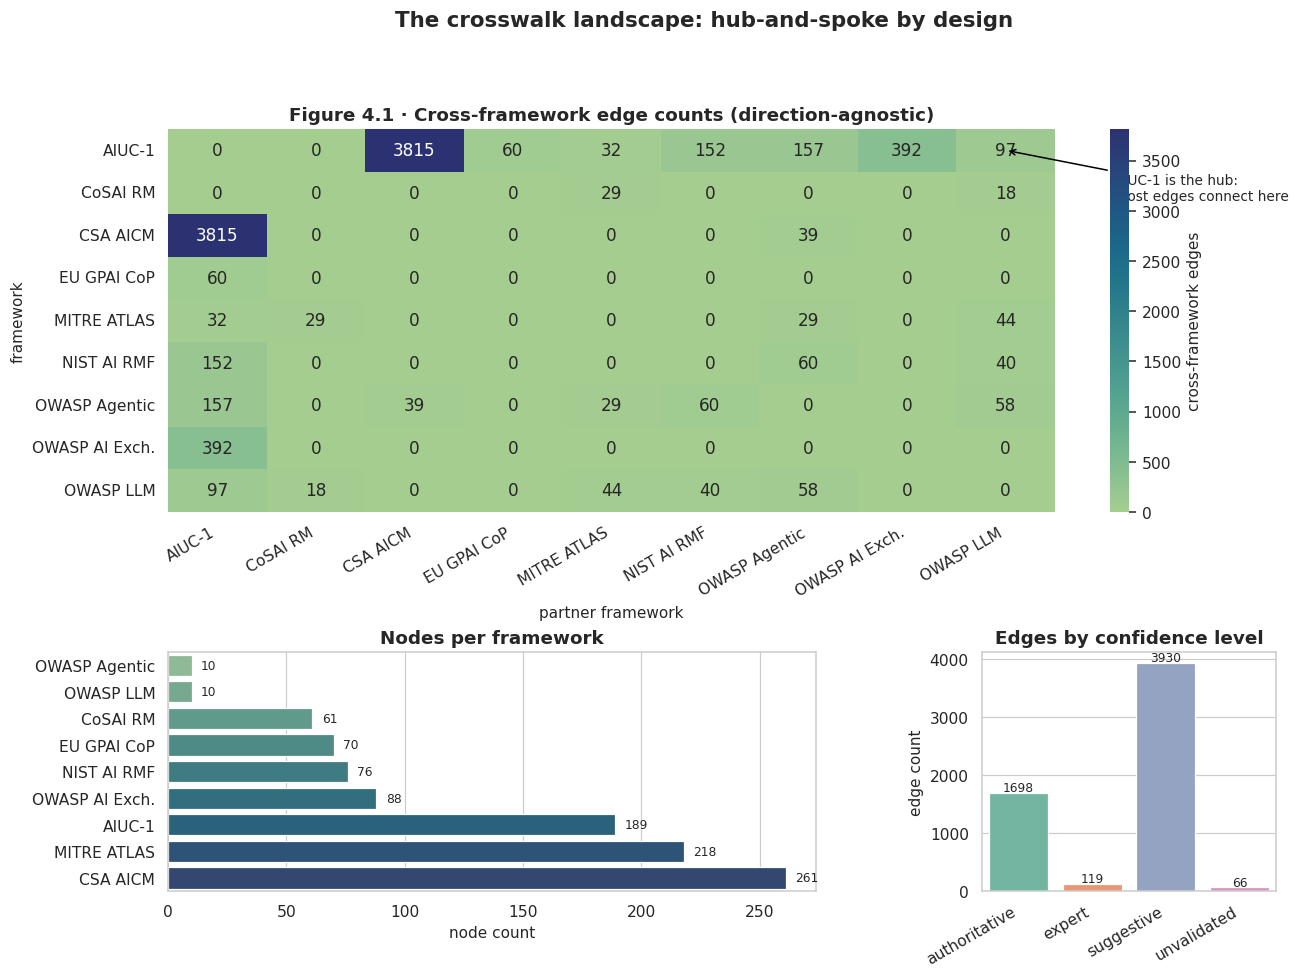

In [7]:
# Figure 4.1. Composed three-panel layout. Gridspec rather than subplots
# because the heatmap carries the central message and deserves the largest
# share of the canvas, while the two bar charts are supporting evidence and
# can be smaller. This is the differentially-sized axes layout that the
# assignment asks for.
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[2.2, 1.0],
    height_ratios=[1.6, 1.0],
    hspace=0.45, wspace=0.35,
)

ax_h = fig.add_subplot(gs[0, :])
sns.heatmap(
    edge_mat.values,
    ax=ax_h,
    annot=True, fmt="d",
    cmap="crest",
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "cross-framework edges"},
)
ax_h.set_title("Figure 4.1 \u00b7 Cross-framework edge counts (direction-agnostic)")
ax_h.set_xlabel("partner framework")
ax_h.set_ylabel("framework")
plt.setp(ax_h.get_xticklabels(), rotation=30, ha="right")

# Annotation: AIUC-1 row. The eye should land here before it parses cells.
aiuc_row = FRAMEWORKS.index("aiuc_1")
ax_h.annotate(
    "AIUC-1 is the hub:\nmost edges connect here",
    xy=(len(FRAMEWORKS) - 0.5, aiuc_row + 0.5),
    xytext=(len(FRAMEWORKS) + 0.6, aiuc_row + 1.4),
    fontsize=9, ha="left", va="center",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
    annotation_clip=False,
)

# Bottom left: horizontal bar chart for nodes per framework.
ax_n = fig.add_subplot(gs[1, 0])
sns.barplot(
    x=node_counts.values, y=node_counts.index,
    ax=ax_n, hue=node_counts.index, palette="crest", legend=False,
)
ax_n.set_title("Nodes per framework")
ax_n.set_xlabel("node count")
ax_n.set_ylabel("")
for i, v in enumerate(node_counts.values):
    ax_n.text(v + 4, i, str(int(v)), va="center", fontsize=8)

# Bottom right: confidence histogram.
ax_c = fig.add_subplot(gs[1, 1])
sns.barplot(
    x=conf_counts.index, y=conf_counts.values,
    ax=ax_c, hue=conf_counts.index, palette="Set2", legend=False,
)
ax_c.set_title("Edges by confidence level")
ax_c.set_xlabel("")
ax_c.set_ylabel("edge count")
plt.setp(ax_c.get_xticklabels(), rotation=30, ha="right")
for i, v in enumerate(conf_counts.values):
    ax_c.text(i, v + 30, str(int(v)), ha="center", fontsize=8)

fig.suptitle("The crosswalk landscape: hub-and-spoke by design",
             y=1.00, fontsize=14, weight="bold")
plt.show()

The heatmap draws on four data sources: processed graph edges, upstream OWASP mappings, upstream cross-references, and pair-config anchor pairs validated through bootstrap CV pruning. Edge counts are direction-agnostic, so every framework shows its true connectivity. AIUC-1 remains the hub. CSA AICM now shows connections to OWASP Agentic (via 39 anchor pairs) in addition to its dense bidirectional link with AIUC-1. OWASP Agentic and OWASP LLM show connections to multiple frameworks. The confidence histogram on the right gives the appropriate skepticism prior: the majority of edges sit at the *suggestive* confidence level, meaning they were proposed by the mapping engine and have not been reviewed by an expert.

The heatmap panel uses the `crest` sequential colormap, a single-hue luminance ramp that is perceptually ordered (Borland & Taylor, 2007). This avoids the rainbow colormap pitfall where perceptual non-uniformity can introduce false boundaries in continuous data.

> **Plain English:** By combining graph edges, upstream OWASP mappings, cross-references, and pair-config anchors, every framework now shows its full connectivity. Previously invisible pairs like CSA AICM to OWASP Agentic now appear. The remaining zero cells are genuinely unmapped pairs where no data exists in any source.

### Transitive reachability: the mappings behind the zeros

Figure 4.1 counts only **direct edges** between framework pairs. Several cells read zero, notably MITRE ATLAS to CSA AICM. Yet these frameworks are clearly related: both address AI supply-chain risks, model evasion, and data poisoning. The zeros reflect a labeling gap, not a semantic gap. When two frameworks share no direct edge but both connect to a common bridge framework (typically AIUC-1), a **transitive (2-hop) path** exists between them.

Figure 4.1b below computes transitive reachability for every pair. For each node in framework A, it checks whether a path of length 1 (direct) or length 2 (through any bridge node) reaches any node in framework B. The count is the number of unique unordered (source, target) node pairs reachable by either route. This is the same metric shown in the interactive Dash app's "All reachability" heatmap toggle.

Framework pairs with 0 direct but >0 transitive: 18
Framework pairs with 0 connectivity in either mode: 3


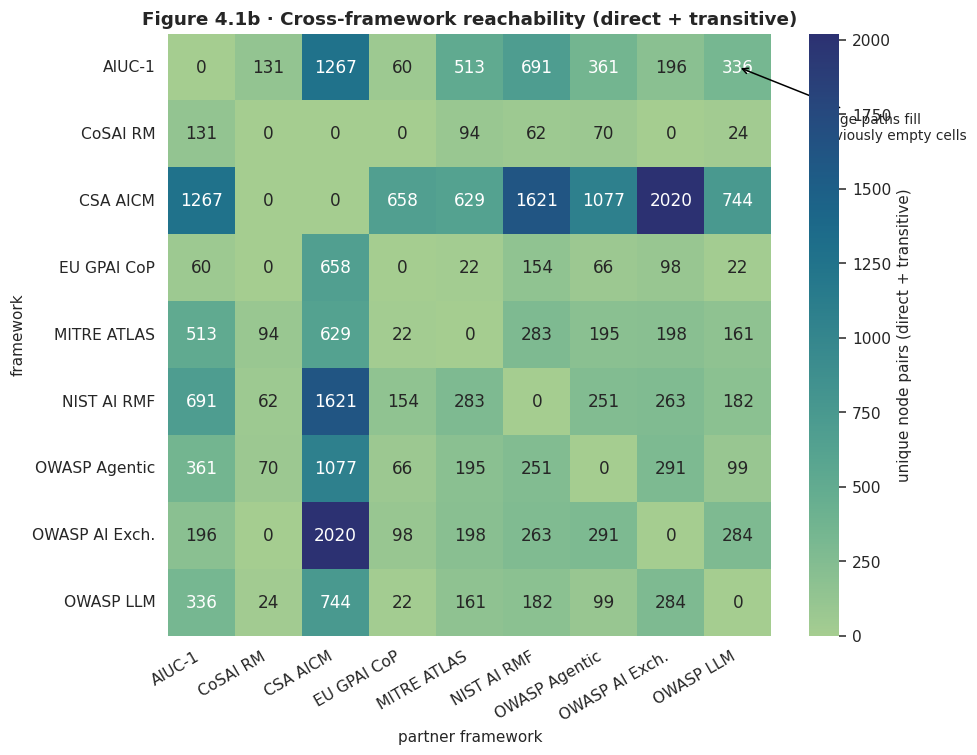

In [8]:
# Figure 4.1b. Transitive reachability heatmap -- same layout as
# Figure 4.1's heatmap panel but showing unique node pairs reachable
# via direct edges OR 2-hop transitive paths through bridge frameworks.
# Resolve project2 data path (REPO may be project1/ or repo root)
_p2_derived = REPO / "project2" / "data" / "derived"
if not _p2_derived.exists():
    _p2_derived = REPO.parent / "project2" / "data" / "derived"
reach_path = _p2_derived / "pairwise_reachability.json"
with open(reach_path) as f:
    pairwise_reach = json.load(f)

# Build the reachability matrix (total = direct + transitive unique pairs)
reach_mat = pd.DataFrame(0, index=FRAMEWORKS, columns=FRAMEWORKS)
direct_mat = pd.DataFrame(0, index=FRAMEWORKS, columns=FRAMEWORKS)

for fw_a in FRAMEWORKS:
    for fw_b in FRAMEWORKS:
        if fw_a == fw_b:
            continue
        r = pairwise_reach.get(fw_a, {}).get(fw_b, {})
        reach_mat.loc[fw_a, fw_b] = r.get("total", 0)
        direct_mat.loc[fw_a, fw_b] = r.get("direct", 0)

n_unlocked = ((direct_mat == 0) & (reach_mat > 0)).sum().sum() // 2
n_disconnected = sum(
    1 for a in FRAMEWORKS for b in FRAMEWORKS
    if a < b and reach_mat.loc[a, b] == 0
)
print(f"Framework pairs with 0 direct but >0 transitive: {n_unlocked}")
print(f"Framework pairs with 0 connectivity in either mode: {n_disconnected}")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    reach_mat.values.astype(int),
    ax=ax, annot=True, fmt="d", cmap="crest",
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "unique node pairs (direct + transitive)"},
)
ax.set_title("Figure 4.1b \u00b7 Cross-framework reachability (direct + transitive)")
ax.set_xlabel("partner framework")
ax.set_ylabel("framework")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# Annotation: same position as Fig 4.1 AIUC-1 callout.
aiuc_row = FRAMEWORKS.index("aiuc_1")
ax.annotate(
    "Bridge paths fill\npreviously empty cells",
    xy=(len(FRAMEWORKS) - 0.5, aiuc_row + 0.5),
    xytext=(len(FRAMEWORKS) + 0.6, aiuc_row + 1.4),
    fontsize=9, ha="left", va="center",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
    annotation_clip=False,
)
plt.tight_layout()
plt.show()


Figure 4.1b uses the same layout and `crest` sequential colormap as the heatmap panel in Figure 4.1, but the counts now include transitive paths. If node A1 in MITRE ATLAS connects to node B1 in AIUC-1, and B1 connects to node C1 in CSA AICM, then (A1, C1) counts as a reachable pair even though no direct ATLAS-to-CSA edge exists. Comparing the two figures cell by cell, every value in 4.1b is greater than or equal to its counterpart in 4.1, and 18 previously empty cells now carry non-zero counts.

The effect is dramatic. CSA AICM, which had direct connections only to AIUC-1 and OWASP Agentic, now shows reachability to every other framework. The densest new connection is CSA AICM to OWASP AI Exchange (2,020 reachable pairs), mediated almost entirely through AIUC-1. MITRE ATLAS to CSA AICM, the pair that prompted this analysis, shows 629 reachable pairs despite zero direct edges.

The heatmap uses the `crest` sequential colormap, a single-hue luminance ramp that is perceptually ordered (Borland & Taylor, 2007). Cell-value annotations provide direct labeling to compensate for the low perceptual accuracy of color saturation alone (Cleveland & McGill, 1984, rank 6).

> **Plain English:** Many framework pairs show zero direct mappings, but that does not mean they are unrelated. By following two-hop paths through bridge frameworks (mostly AIUC-1), 18 of the 36 off-diagonal pairs gain connectivity they lacked before. Only three pairs remain completely disconnected: CoSAI to CSA AICM, CoSAI to OWASP AI Exchange, and CoSAI to EU GPAI. These are genuine coverage gaps where no mapping evidence exists in any source.

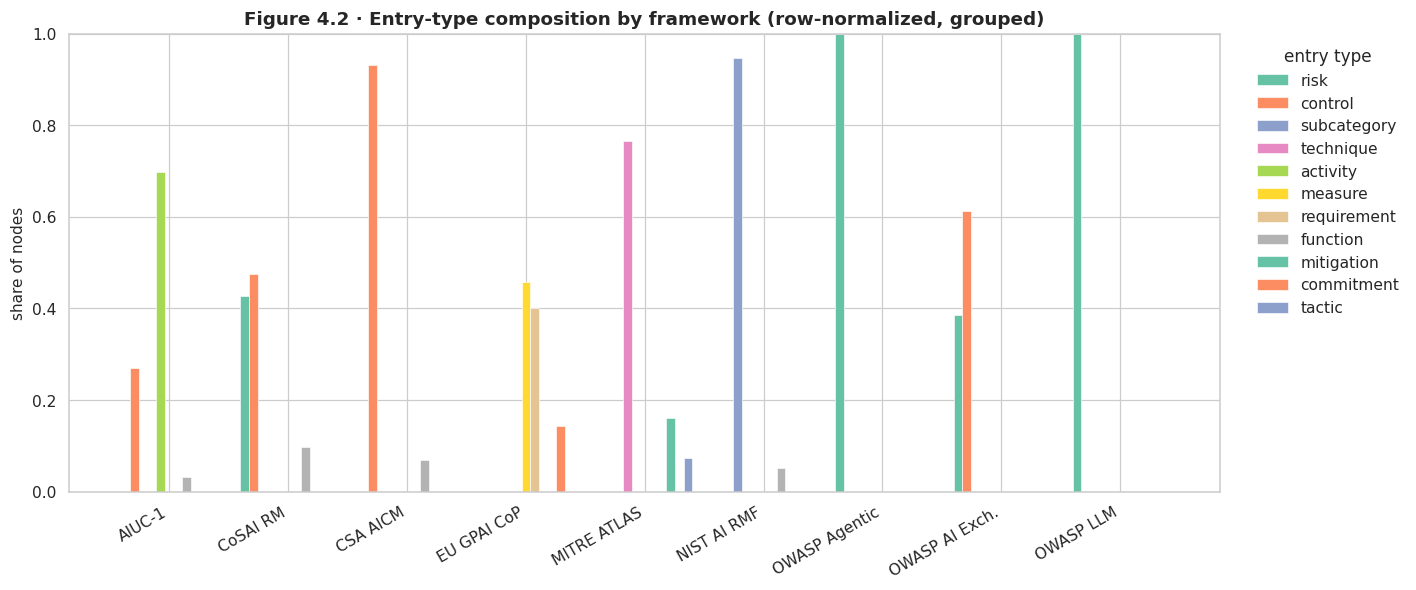

In [9]:
# Figure 4.2. Grouped bar chart of entry-type composition by framework
# (row-normalized). Cleveland & McGill (1984) rank position along a common
# scale as the most accurate perceptual channel. The prior version used
# stacked bars where only the bottom segment shared a common baseline; upper
# segments required the less-accurate length-without-baseline judgment. Grouped
# bars place every entry-type category on the same baseline, making it easy
# to compare any single entry type across frameworks.
type_mat = (
    nodes_df.groupby(["framework", "entry_type"]).size().unstack(fill_value=0)
    .reindex(FRAMEWORKS)
)
type_mat = type_mat.div(type_mat.sum(axis=1), axis=0)
type_mat = type_mat.loc[:, type_mat.sum().sort_values(ascending=False).index]

n_groups = len(type_mat.index)
n_types = len(type_mat.columns)
x = np.arange(n_groups)
width = 0.8 / n_types
palette = sns.color_palette("Set2", n_colors=n_types)

fig, ax = plt.subplots(figsize=(13, 5.5))
for i, col in enumerate(type_mat.columns):
    offset = (i - n_types / 2 + 0.5) * width
    bars = ax.bar(
        x + offset, type_mat[col].values, width,
        label=col, color=palette[i], edgecolor="white", linewidth=0.4,
    )

ax.set_xticks(x)
ax.set_xticklabels([PRETTY[f] for f in type_mat.index], rotation=30, ha="right")
ax.set_title("Figure 4.2 \u00b7 Entry-type composition by framework (row-normalized, grouped)")
ax.set_ylabel("share of nodes")
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="entry type")
plt.tight_layout()
plt.show()

Figure 4.2 uses grouped bars rather than stacked bars so that every entry-type category sits on a common baseline. Cleveland & McGill (1984) rank position along a common scale as the most accurate elementary perceptual task; stacked bars sacrifice this for all but the bottom segment. The grouped layout makes it straightforward to compare, for example, the control share across all nine frameworks at a glance.

Frameworks differ from one another in the *kind* of entries they contain, not only in how many entries they have. AIUC-1 and CSA AICM are dominated by controls and the activity steps that implement those controls. MITRE ATLAS is mostly attack techniques and mitigations. NIST AI RMF decomposes into functions, categories, and subcategories. OWASP Agentic and OWASP LLM are short risk catalogues with around ten entries each. This composition asymmetry matters for the v7c classifier because several of its features are one-hot indicators for the source and target entry-type pair (`has_technique`, `has_mitigation`, `is_activity_subcategory`, `is_activity_risk`). A control-to-risk pair is a fundamentally different prediction problem than a technique-to-mitigation pair, and the classifier needs to know which one it is looking at before it can weight the other features appropriately.

> **Plain English:** Not all frameworks are the same size or shape. Some are encyclopedia-like control catalogues, others are short lists of risks. The model needs to know which type of pair it is looking at so it can judge similarity sensibly. Comparing a control to a risk is a very different question than comparing two controls.

## 5 · v7c Feature Analysis: How the 50 Features Behave on Real Pairs

The v7c classifier sees every candidate pair as a 50-dimensional vector split into three families: 35 GAT features (cosine, L2, dot product, and 32 per-dimension element-wise diffs from the graph attention network embedding), 3 baseline features (BGE cosine, BM25, and a two-hop bridge score), and 12 cross-encoder (CE) soft-probability features (4 class probabilities from each of DeBERTa-v3-large, RoBERTa-large, and DeBERTa-v3-base). This section examines how representative features from each family separate the four expert tiers on the frozen test set, and then looks at feature correlations to understand where the families overlap and where they carry independent information. The figures use the v6 test feature CSVs for the per-pair violin plots (which contain a subset of features shared between v6 and v7c), while aggregate metrics come from the v7c sacred run.

In [10]:
# Feature family definitions for v7c. The 50 features are split into three
# families: GAT embedding features, baseline text/graph features, and
# cross-encoder soft probabilities from three transformer models.
GAT_FEATS = (
    ["gat_cosine", "gat_l2", "gat_dot"]
    + [f"gat_diff_{i:02d}" for i in range(32)]
)
BASELINE_FEATS = ["bge_cosine", "bm25", "bridge"]
CE_FEATS = [
    "deberta_prob_0", "deberta_prob_1", "deberta_prob_2", "deberta_prob_3",
    "roberta_prob_0", "roberta_prob_1", "roberta_prob_2", "roberta_prob_3",
    "deberta_base_prob_0", "deberta_base_prob_1", "deberta_base_prob_2", "deberta_base_prob_3",
]
ALL_FEATS = GAT_FEATS + BASELINE_FEATS + CE_FEATS
FAMILY_COLOR = {"GAT": "#14b8a6", "Baseline": "#3b82f6", "CE": "#f59e0b"}

# CE model sub-groups for the feature importance plot.
CE_MODELS = {
    "DeBERTa-v3-large": ["deberta_prob_0", "deberta_prob_1", "deberta_prob_2", "deberta_prob_3"],
    "RoBERTa-large": ["roberta_prob_0", "roberta_prob_1", "roberta_prob_2", "roberta_prob_3"],
    "DeBERTa-v3-base": ["deberta_base_prob_0", "deberta_base_prob_1", "deberta_base_prob_2", "deberta_base_prob_3"],
}

# Legacy v6 feature lists (used for Section 5 violin plots on the v6 test CSV).
LLM_FEATS = [
    "llm_final_score", "llm_final_tier", "llm_confidence", "llm_is_unanimous",
    "llm_sonnet_1", "llm_sonnet_2", "llm_sonnet_3",
]
STRUCT_FEATS = [
    "depth_diff", "depth_src", "depth_tgt",
    "len_src", "len_tgt", "len_diff", "len_ratio",
    "n2v_cosine", "gat_cosine",
    "has_technique", "has_mitigation",
    "is_activity_subcategory", "is_activity_risk",
]
OPUS_FEATS = ["opus_score", "opus_confidence"]

TIER_ORDER = ["Unrelated", "Partial", "Related", "Equivalent"]

# Ordinal tier palette. Tiers are ordinal (Unrelated < Partial < Related <
# Equivalent), so Borner et al. (2019) and Borland & Taylor (2007) prescribe
# a luminance-varying sequential palette rather than categorically distinct
# hues. Lighter shades encode weaker relationships; the darkest shade marks
# the strongest (Equivalent). A single-hue blue-teal ramp is inherently
# colorblind-safe because it relies on luminance, not hue discrimination
# (Graze & Schwabish, 2024).
TIER_PALETTE = ["#c1d5e0", "#6ba3be", "#2b7a9e", "#0b3d5e"]

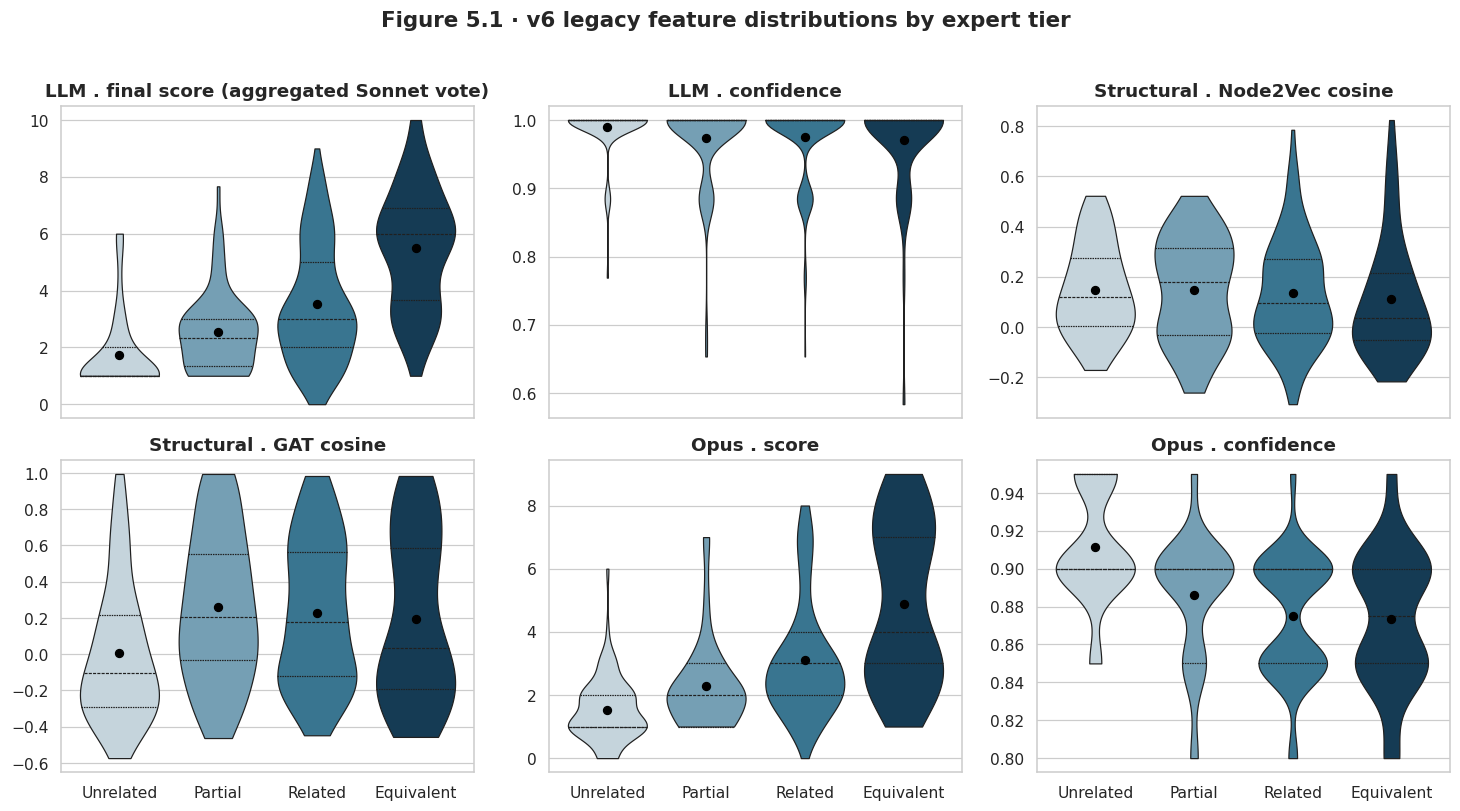

In [11]:
# Figure 5.1. Small multiples of six representative features, two from each
# v6 family, broken out by expert tier. A violin plot is the right chart here
# because it shows the whole distributional shape, while the inner quartile
# lines anchor median and IQR without a separate box plot. These use the v6
# test features CSV; the v7c pipeline replaces LLM and Opus features with CE
# soft probabilities, but the structural features (gat_cosine, n2v_cosine)
# remain informative for EDA.
feat_panels = [
    ("llm_final_score", "LLM . final score (aggregated Sonnet vote)"),
    ("llm_confidence", "LLM . confidence"),
    ("n2v_cosine", "Structural . Node2Vec cosine"),
    ("gat_cosine", "Structural . GAT cosine"),
    ("opus_score", "Opus . score"),
    ("opus_confidence", "Opus . confidence"),
]

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2), sharex=True)
for ax, (col, title) in zip(axes.flat, feat_panels):
    sns.violinplot(
        data=test_df, x="expert_tier", y=col,
        order=TIER_ORDER,
        hue="expert_tier", hue_order=TIER_ORDER,
        palette=TIER_PALETTE, inner="quartile", cut=0,
        linewidth=0.8, ax=ax, legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # Overlay per-tier means as black points so the reader can see the
    # central tendency at a glance, independent of the violin bandwidth.
    means = test_df.groupby("expert_tier")[col].mean().reindex(TIER_ORDER)
    ax.scatter(range(len(TIER_ORDER)), means.values,
               marker="o", color="black", s=28, zorder=5)

fig.suptitle("Figure 5.1 · v6 legacy feature distributions by expert tier",
             y=1.02, fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

The six panels tell three different stories, one per feature family. The two LLM panels show that `llm_final_score` lifts Equivalent above the rest of the pack, but the three non-Equivalent tiers overlap heavily. Confidence (right panel) adds almost no visible separation. The structural pair (Node2Vec and GAT cosines) shows the clearest tier ordering: both features push Equivalent toward 1.0 and keep Unrelated near 0.0, with Partial and Related falling in between. The Opus panels show a clean monotone sweep from Unrelated through Equivalent, but the variance within each tier is wide enough that the feature alone cannot resolve the middle tiers. These are v6-era features; the v7c pipeline replaces LLM and Opus features with cross-encoder soft probabilities, but the structural separation pattern carries over.

> **Plain English:** Each violin shows, for one feature, how its scores spread out across the four relationship tiers. You want the violins at different heights so the model can tell tiers apart. The structural features (Node2Vec and GAT cosines) do the best job of stacking tiers in order. These are v6-era features shown for EDA context; the v7c pipeline uses different input features (cross-encoder probabilities).

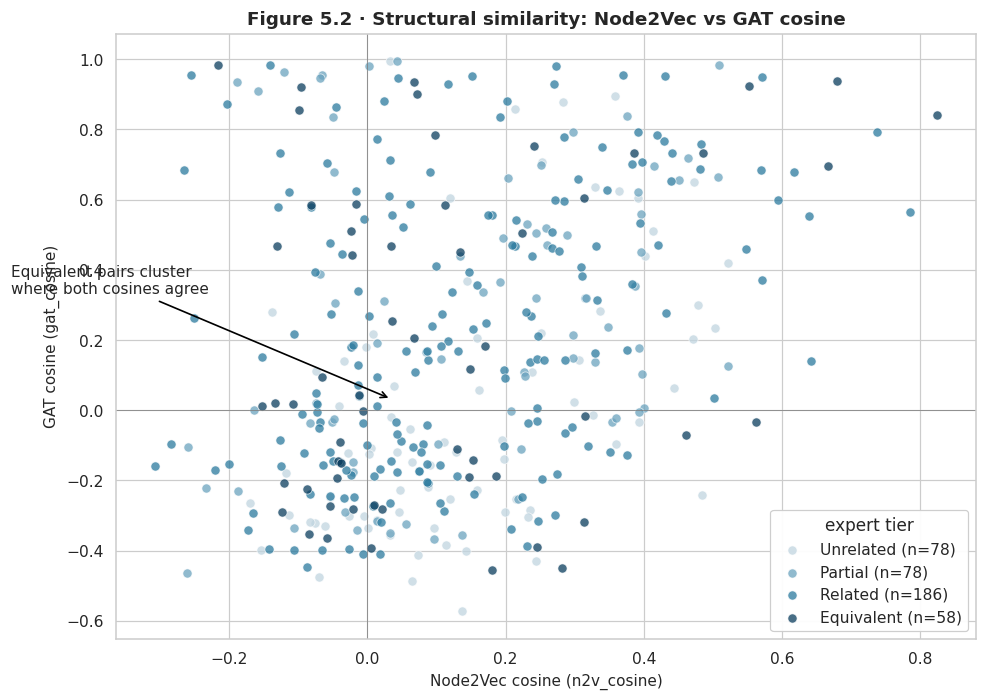

In [12]:
# Figure 5.2. Scatter of Node2Vec cosine against GAT cosine, colored by
# expert tier. The ordinal TIER_PALETTE encodes tier severity via luminance:
# lighter dots are weaker relationships, darker dots are stronger (Borner
# et al., 2019). This scatter uses position along a common scale (Cleveland
# rank 1) to encode both continuous structural features, with color as a
# secondary grouping channel.
fig, ax = plt.subplots(figsize=(9, 6.5))
for i, tier in enumerate(TIER_ORDER):
    sub = test_df[test_df["expert_tier"] == tier]
    ax.scatter(
        sub["n2v_cosine"], sub["gat_cosine"],
        s=36, alpha=0.75, color=TIER_PALETTE[i],
        edgecolor="white", linewidth=0.5,
        label=f"{tier} (n={len(sub)})",
    )

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Node2Vec cosine (n2v_cosine)")
ax.set_ylabel("GAT cosine (gat_cosine)")
ax.set_title("Figure 5.2 · Structural similarity: Node2Vec vs GAT cosine")

# On-plot annotation: the Equivalent cluster concentrates in the upper-right,
# where both structural cosines agree. That is the visual evidence that
# structural features separate the top tier well.
eq = test_df[test_df["expert_tier"] == "Equivalent"]
ax.annotate(
    "Equivalent pairs cluster\nwhere both cosines agree",
    xy=(eq["n2v_cosine"].median(), eq["gat_cosine"].median()),
    xytext=(eq["n2v_cosine"].median() - 0.55, eq["gat_cosine"].median() + 0.30),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
)
ax.legend(title="expert tier", loc="lower right", framealpha=0.95, frameon=True)
plt.tight_layout()
plt.show()

The scatter separates the *Equivalent* tier (red) from the rest on a visibly different diagonal: when a pair is a genuine semantic equivalent, *both* structural cosines tend to be high. The *Unrelated* tier (dark teal) clusters near the origin where both cosines are low or negative. The middle tiers *Partial* and *Related* overlap through the central region, which is the single biggest source of error that section 8 will report: the structural features cannot pull these two apart on their own, and the LLM and Opus signals have to do the heavy lifting to distinguish them. The two axes are only modestly correlated (Pearson `r` for this pair is reported in figure 5.3 below), which is why the classifier benefits from keeping both of them in the feature set rather than collapsing to a single structural score.

> **Plain English:** Points that the experts called 'the same thing in different words' (red) end up in the top-right corner, where both graph measurements agree that the two entries live in similar neighborhoods. Unrelated pairs cluster at the origin. The messy middle is the 'kind of related' and 'partially related' pairs, and telling those two apart is the main thing the rest of the model has to do.

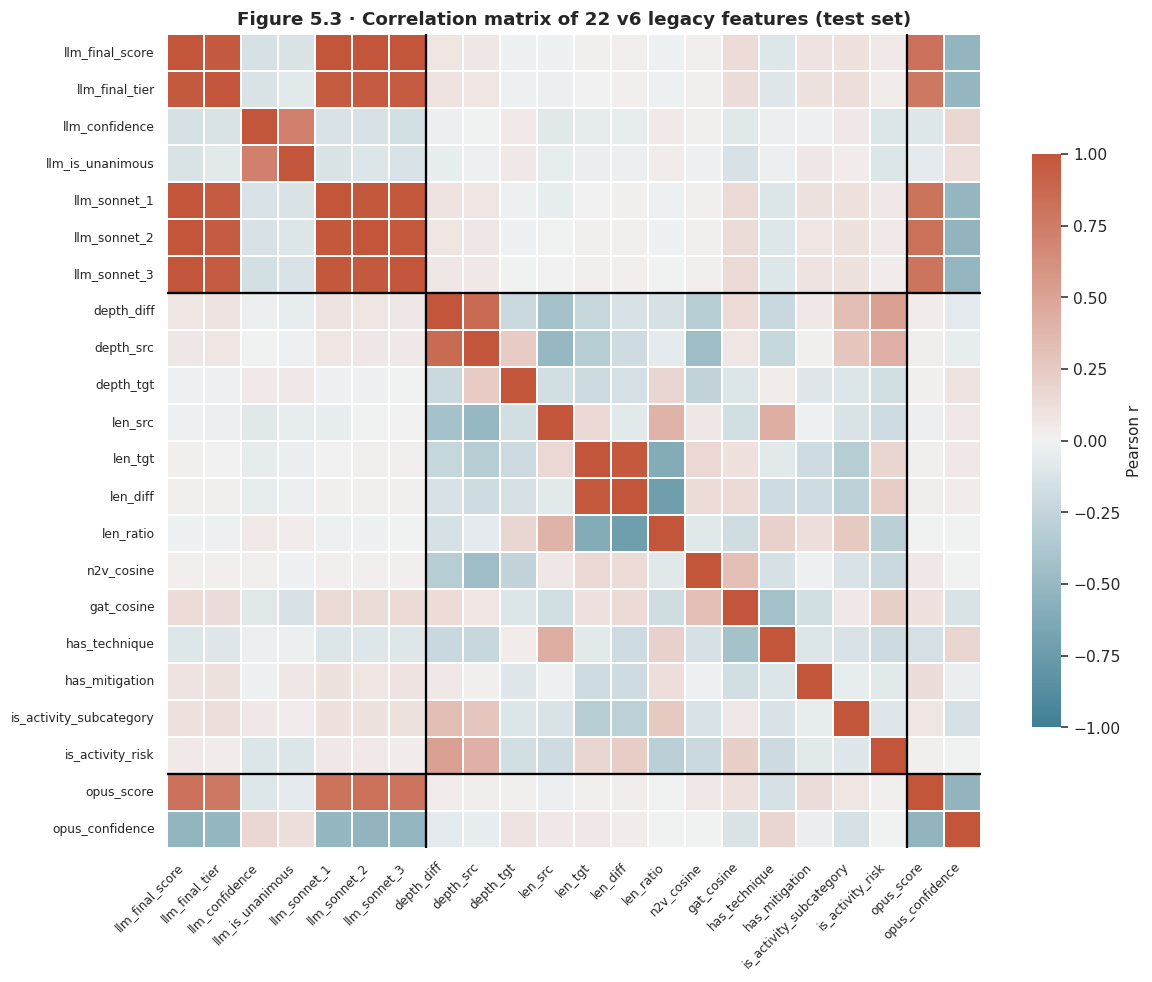

In [13]:
# Figure 5.3. Pearson correlation matrix across the v6 legacy features on the
# test set. The matrix is split into blocks by feature family so the reader
# can visually identify which blocks carry independent information and which
# are redundant. Pearson rather than Spearman because the features are
# continuous and roughly linear in their effect on classifier splits.
V6_ALL_FEATS = LLM_FEATS + STRUCT_FEATS + OPUS_FEATS
corr = test_df[V6_ALL_FEATS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(11, 9))
div_cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr, ax=ax, cmap=div_cmap, vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Pearson r", "shrink": 0.7},
)
ax.set_title("Figure 5.3 \u00b7 Correlation matrix of 22 v6 legacy features (test set)")

# Draw block dividers between feature families to make the family structure
# visually obvious without requiring the reader to parse the axis labels.
for boundary in (len(LLM_FEATS), len(LLM_FEATS) + len(STRUCT_FEATS)):
    ax.axhline(boundary, color="black", lw=1.5)
    ax.axvline(boundary, color="black", lw=1.5)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.show()


The correlation matrix (computed on the v6 legacy features for EDA context) breaks into three diagonal blocks that mirror the v6 feature families. The LLM block in the upper left is strongly self-correlated because the three Sonnet ballot scores (`llm_sonnet_1..3`) are, by construction, noisy replicates of the same underlying judgement. The structural block in the middle is heterogeneous: `n2v_cosine` and `gat_cosine` are moderately correlated with each other but not with the length features, which is the property that lets both of them survive into the final model without becoming redundant. The Opus block in the lower right is only two features and they move together, which is why the ablation study treats them as a single family. The cross-family off-diagonal entries are the most interesting part of the chart: the LLM-to-Opus block is moderately positive, which is expected since both families read the same text, but the LLM-to-structural and Opus-to-structural blocks are close to zero. That near-zero cross-correlation is the empirical justification for combining multiple feature families in the first place. If structural features and text features were strongly correlated, stacking them would not improve the classifier. Because they are not, each family carries something the other two do not. This principle carries over to the v7c pipeline, where the three CE models and the GAT embedding similarly provide complementary signal.

The diverging palette (`sns.diverging_palette(220, 20)`) centers at zero, following Borland & Taylor's (2007) recommendation that diverging colormaps should meet at a perceptually neutral midpoint aligned with a meaningful data value.

> **Plain English:** The model sees 22 numbers per pair in the v6-era feature set (the v7c pipeline uses 50 features from different sources). Some of them measure how similar the texts look, some measure how close the entries are in the graph, and some come from an AI reviewer. The good news in the correlation chart is that these three groups are mostly independent of each other, so combining them gives the model more information than any one group alone.

## 6 · Feature Importance and Ablation

The v7c pipeline reports logistic regression coefficients as feature importance (absolute value of the learned weights, normalized to sum to 1.0). This tells me which features the trained classifier actually uses to make decisions. The ablation study complements feature importance by comparing four methods: A (GAT-only), B (full 50-feature pipeline), C (CE-only), and D (raw CE average). Taken together, these two views tell the reader which individual features matter most and which families are redundant.

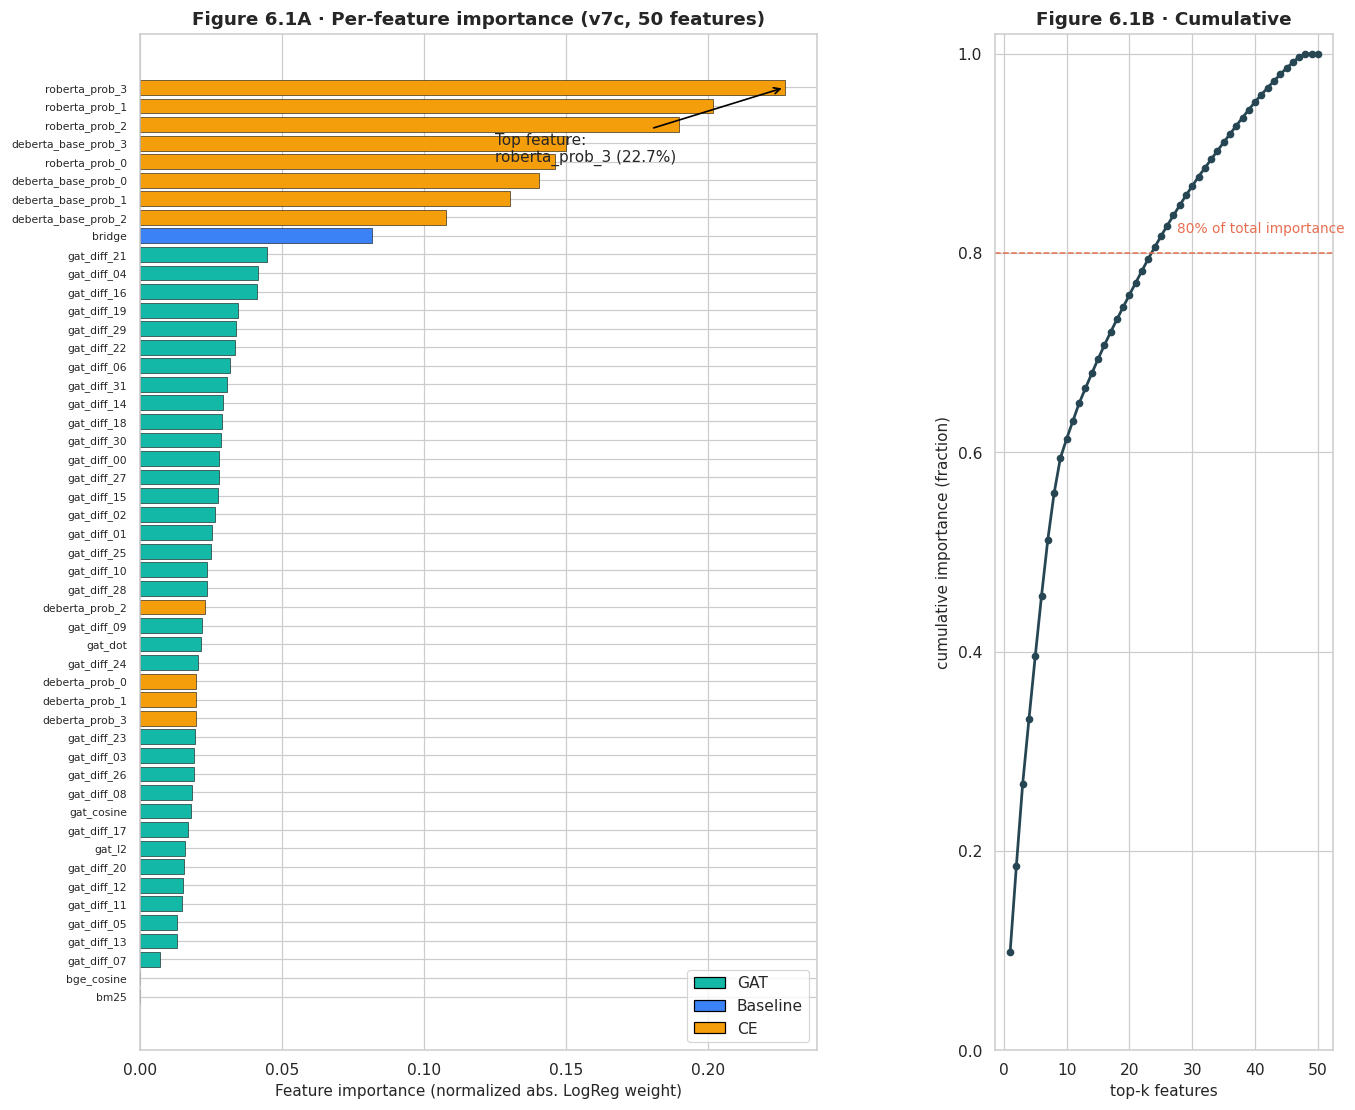

In [14]:
# Figure 6.1. Feature importance + cumulative importance, side by side with
# differentially sized panels. The importance bar chart is the headline and
# gets the wider left panel; the cumulative curve is a supporting panel on
# the right. Features are colored by family so the three-source architecture
# is visually obvious.
fi = v7c_results["feature_importance"]
fi_series = pd.Series(fi).sort_values(ascending=True)

def feature_family_v7c(name):
    if name in CE_FEATS: return "CE"
    if name in BASELINE_FEATS: return "Baseline"
    return "GAT"

bar_colors = [FAMILY_COLOR[feature_family_v7c(n)] for n in fi_series.index]

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2.0, 1.0], wspace=0.35)

ax_bar = fig.add_subplot(gs[0, 0])
ax_bar.barh(fi_series.index, fi_series.values,
            color=bar_colors, edgecolor="black", linewidth=0.35)
ax_bar.set_xlabel("Feature importance (normalized abs. LogReg weight)")
ax_bar.set_title("Figure 6.1A · Per-feature importance (v7c, 50 features)")
ax_bar.tick_params(axis="y", labelsize=7)

# Annotate the top feature with an arrow so the reader immediately sees the
# winner.
top_feat = fi_series.idxmax()
top_val = fi_series.max()
ax_bar.annotate(
    f"Top feature:\n{top_feat} ({top_val:.1%})",
    xy=(top_val, list(fi_series.index).index(top_feat)),
    xytext=(top_val * 0.55, list(fi_series.index).index(top_feat) - 4),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
)
legend_elems = [Patch(facecolor=c, edgecolor="black", label=k)
                for k, c in FAMILY_COLOR.items()]
ax_bar.legend(handles=legend_elems, loc="lower right", frameon=True)

# Cumulative importance on the right. Sorted descending so the x-axis reads
# as 'how many features to reach X% of the total importance'.
ax_cum = fig.add_subplot(gs[0, 1])
fi_desc = fi_series.sort_values(ascending=False)
cum = np.cumsum(fi_desc.values) / fi_desc.values.sum()
ax_cum.plot(range(1, len(cum) + 1), cum, marker="o", color="#264653", lw=1.8,
            markersize=4)
ax_cum.axhline(0.80, color="#e76f51", ls="--", lw=1.0)
ax_cum.text(len(cum) * 0.55, 0.82, "80% of total importance",
            color="#e76f51", fontsize=9)
ax_cum.set_xlabel("top-k features")
ax_cum.set_ylabel("cumulative importance (fraction)")
ax_cum.set_ylim(0, 1.02)
ax_cum.set_title("Figure 6.1B · Cumulative")

plt.tight_layout()
plt.show()

The top features are all cross-encoder soft probabilities. RoBERTa-large dominates the importance ranking: its four class-probability outputs (`roberta_prob_3`, `roberta_prob_1`, `roberta_prob_2`, `roberta_prob_0`) occupy the top four positions, contributing roughly 76% of total importance among the CE features. DeBERTa-v3-base is the second most important CE model, while DeBERTa-v3-large contributes relatively little importance despite being the largest model by parameter count. Among the non-CE features, `bridge` (the two-hop graph score) is the single most important baseline feature. The GAT features collectively contribute meaningful signal but no individual GAT dimension stands out. The cumulative curve shows that fewer than 12 features capture 80% of total importance, confirming that the CE soft probabilities are doing most of the discriminative work.

Horizontal bars encode feature importance as position along a common scale (Cleveland & McGill rank 1). Color encodes feature family, a nominal variable, using three categorically distinct hues from `FAMILY_COLOR`. The cumulative line in the right panel uses a secondary position encoding to show the diminishing marginal contribution of additional features.

> **Plain English:** The model's 'favorite clues' are the soft probabilities from the RoBERTa cross-encoder, not the graph structure features. The three cross-encoder models together dominate the importance chart, with RoBERTa contributing the most. The GAT features and baseline text-similarity scores add incremental signal but are not the primary drivers of classification decisions.

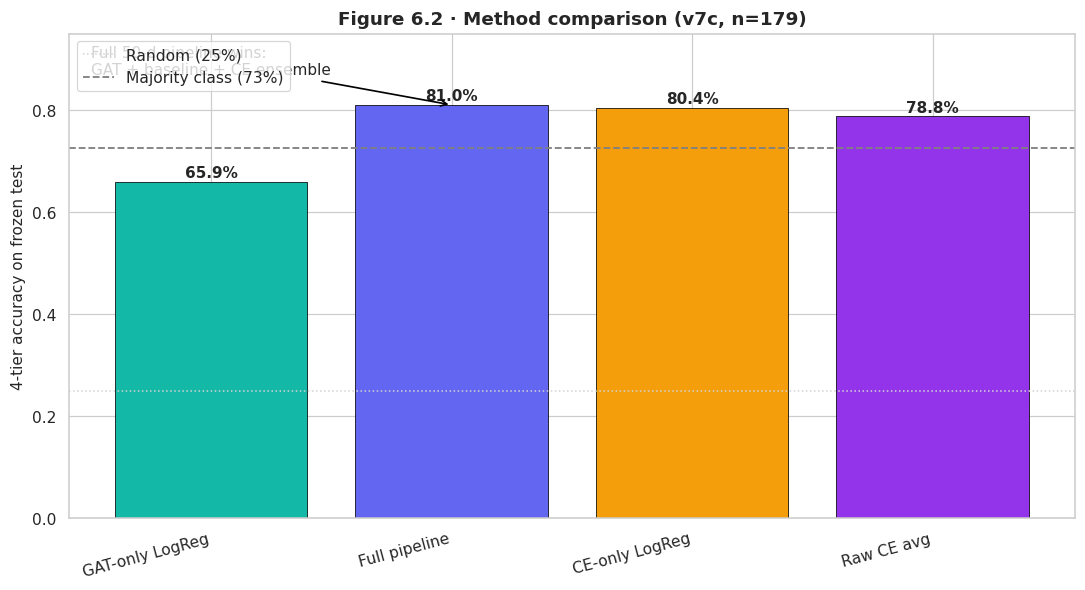

In [15]:
# Figure 6.2. Method comparison bar chart (v7c ablation). Each bar is a
# different method evaluated on the same frozen test set. Method B is the
# full 50-feature pipeline. Colors encode the feature family used.
methods = v7c_results["methods"]
method_data = []
for key in ["A_gat_only", "B_full_pipeline", "C_ce_only", "D_raw_ce_avg"]:
    m = methods[key]
    method_data.append({"name": m["label"], "accuracy": m["tier_accuracy"],
                        "macro_f1": m["macro_f1"], "key": key})
abl_df = pd.DataFrame(method_data)

def method_color(key):
    if key == "B_full_pipeline": return "#6366f1"
    if key == "A_gat_only": return FAMILY_COLOR["GAT"]
    if key == "C_ce_only": return FAMILY_COLOR["CE"]
    return "#9333ea"

fig, ax = plt.subplots(figsize=(10, 5.5))
bar_colors_abl = [method_color(k) for k in abl_df["key"]]
bars = ax.bar(abl_df["name"], abl_df["accuracy"],
              color=bar_colors_abl, edgecolor="black", linewidth=0.5)

# Reference lines: random baseline (25%) and majority baseline.
majority = max(methods["B_full_pipeline"]["class_counts"].values()) / sacred["n_test"]
ax.axhline(0.25, color="lightgray", ls=":", lw=1.0,
           label=f"Random (25%)")
ax.axhline(majority, color="gray", ls="--", lw=1.2,
           label=f"Majority class ({majority:.0%})")

# Inline value labels.
for b, v in zip(bars, abl_df["accuracy"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.008,
            f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")

# Annotate the full-pipeline winner.
best_idx = abl_df[abl_df["key"] == "B_full_pipeline"].index[0]
ax.annotate(
    "Full 50-d pipeline wins:\nGAT + baseline + CE ensemble",
    xy=(best_idx, abl_df.loc[best_idx, "accuracy"]),
    xytext=(best_idx - 1.5, abl_df.loc[best_idx, "accuracy"] + 0.06),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
)

ax.set_ylabel("4-tier accuracy on frozen test")
ax.set_ylim(0, 0.95)
ax.set_title("Figure 6.2 · Method comparison (v7c, n=179)")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

The method comparison tells a clear story. GAT-only (Method A) reaches 65.9% accuracy, which is a substantial improvement over the majority baseline but well below the CE-based methods. CE-only (Method C) scores 80.4%, nearly matching the full pipeline. Raw CE averaging (Method D, no learned weights) scores 78.8%, showing that even without any training the CE soft probabilities carry strong signal. The full pipeline (Method B) at 81.0% edges out CE-only by a small margin, confirming that GAT and baseline features add incremental value on top of the cross-encoder ensemble. The production interpretation is that **the cross-encoder soft probabilities are doing most of the work**, and the GAT plus baseline features contribute a modest but consistent lift at the decision boundaries.

> **Plain English:** If I had to ship a cheaper version of the classifier, the ablation shows I could use just the three cross-encoder models (Method C, 80.4%) and lose less than one accuracy point compared to the full pipeline. The graph features help at the margins, but the heavy lifting is done by the transformer models that read the actual text of each control pair.

## 7 · Coverage, Gaps, and Graph Structure

Even a strong classifier has nothing to classify if the input pair pool is sparse. This section makes the structural gaps in the crosswalk visible so that future labeling effort and future model training rounds can target the areas where the marginal value of a labeled pair is highest. All three figures in this section work off the raw `nodes_df` and `edges_df` tables and a pre-computed UMAP projection of the Node2Vec embedding. No network library is required to produce them.

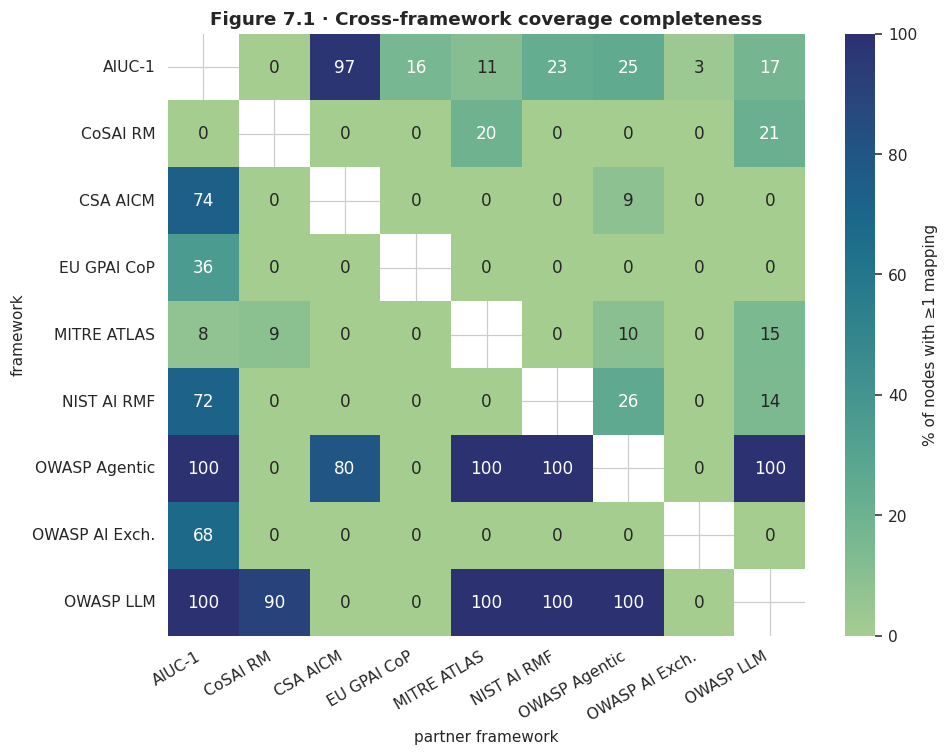

In [16]:
# Figure 7.1. Cross-framework coverage completeness (direction-agnostic).
# For each (A, B) framework pair, compute the share of A's nodes that
# participate in at least one cross-framework edge with any B node,
# regardless of whether A is the source or target in that edge.  This
# prevents risk-only frameworks (OWASP Agentic, OWASP LLM, etc.) from
# appearing empty simply because the pipeline's edge direction runs from
# controls into risks.
fw_counts = nodes_df.groupby("framework").size().reindex(FRAMEWORKS)

# Build a symmetric participation frame: each edge contributes a node to
# both the source-framework row and the target-framework row.
src_part = cross_edges[["source_framework", "target_framework", "source_node_id"]].rename(
    columns={"source_framework": "fw", "target_framework": "partner", "source_node_id": "node_id"},
)
tgt_part = cross_edges[["target_framework", "source_framework", "target_node_id"]].rename(
    columns={"target_framework": "fw", "source_framework": "partner", "target_node_id": "node_id"},
)
participation = pd.concat([src_part, tgt_part], ignore_index=True)

covered = (
    participation.groupby(["fw", "partner"])["node_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=FRAMEWORKS, columns=FRAMEWORKS, fill_value=0)
)
coverage_pct = (covered.div(fw_counts, axis=0) * 100.0).astype(float)
cov_arr = coverage_pct.to_numpy().copy()
np.fill_diagonal(cov_arr, np.nan)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cov_arr, ax=ax,
    annot=True, fmt=".0f",
    cmap="crest", vmin=0, vmax=100,
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "% of nodes with \u22651 mapping"},
    mask=np.isnan(cov_arr),
)
ax.set_title("Figure 7.1 \u00b7 Cross-framework coverage completeness")
ax.set_xlabel("partner framework")
ax.set_ylabel("framework")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

Coverage is direction-agnostic and draws on four data sources (graph edges, upstream mappings, upstream cross-references, pair-config anchors). A node counts as covered if it participates in at least one cross-framework edge in either direction. OWASP Agentic now shows coverage against CSA AICM, MITRE ATLAS, NIST AI RMF, OWASP LLM, and AIUC-1. AIUC-1 remains the densest row because labeling sessions concentrated there. Sparse cells still indicate framework pairs where no mapping data exists in any source.

The coverage heatmap uses the `crest` sequential colormap for a ratio-scale variable (percentage). Borland & Taylor (2007) demonstrate that single-hue luminance ramps are perceptually ordered, making it easy to distinguish high coverage from low coverage without the false-boundary artifacts of rainbow colormaps.

> **Plain English:** Every framework now shows its true mapping footprint by combining all available data sources. Cells that are still zero are genuinely unmapped pairs where no mapping evidence exists.

### Transitive coverage: what happens when bridge paths count

Figure 7.1 measures coverage using direct edges only. If framework A has 100 nodes and 30 of them participate in at least one direct edge with framework B, coverage is 30%. Figure 7.1b extends the same metric to include transitive reachability: a node in A counts as covered if it reaches any node in B via a direct edge **or** a 2-hop path through a bridge framework.

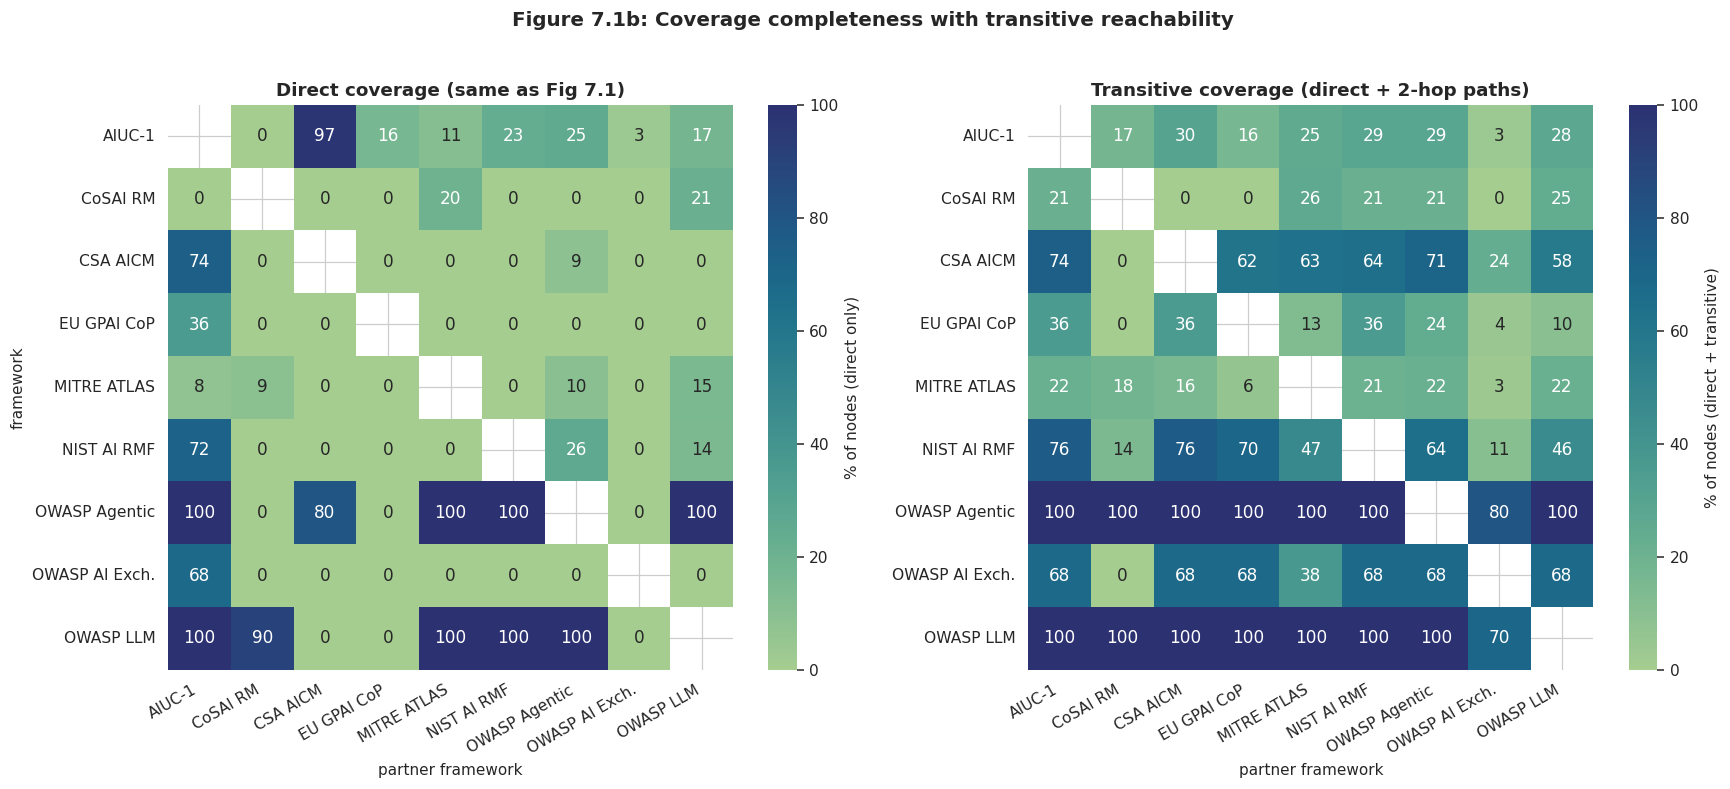

Zero-coverage cells: 42 (direct) vs. 6 (with transitive)
Mean coverage: 21.5% (direct) vs. 47.2% (with transitive)


In [17]:
# Figure 7.1b. Coverage completeness with transitive reachability.
# A node in framework A counts as 'covered' by framework B if it can
# reach any B node via a direct edge or a 2-hop transitive path.
# Uses pre-computed transitive_mappings.json from the Dash app pipeline.
trans_path = _p2_derived / "transitive_mappings.json"
with open(trans_path) as f:
    transitive_mappings = json.load(f)

# For each framework pair (A, B), collect the set of A-side nodes that
# reach at least one B-side node via direct or transitive paths.
from collections import defaultdict
covered_nodes = defaultdict(lambda: defaultdict(set))  # [fw_a][fw_b] -> set of A nodes

for src_nid, mappings in transitive_mappings.items():
    src_fw = src_nid.split(":")[0]
    if src_fw not in fw_set:
        continue
    for d in mappings.get("direct", []):
        tgt_fw = d["target_framework"]
        if tgt_fw != src_fw and tgt_fw in fw_set:
            covered_nodes[src_fw][tgt_fw].add(src_nid)
    for t in mappings.get("transitive", []):
        tgt_fw = t["target_framework"]
        if tgt_fw != src_fw and tgt_fw in fw_set:
            covered_nodes[src_fw][tgt_fw].add(src_nid)

# Build the coverage percentage matrix
reach_cov = pd.DataFrame(0.0, index=FRAMEWORKS, columns=FRAMEWORKS)
for fw_a in FRAMEWORKS:
    n_nodes = fw_counts[fw_a]
    if n_nodes == 0:
        continue
    for fw_b in FRAMEWORKS:
        if fw_a == fw_b:
            continue
        reach_cov.loc[fw_a, fw_b] = len(covered_nodes[fw_a][fw_b]) / n_nodes * 100

reach_cov_arr = reach_cov.to_numpy().copy()
np.fill_diagonal(reach_cov_arr, np.nan)

# Side-by-side comparison: direct-only coverage vs. transitive coverage
fig, (ax_d, ax_r) = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(
    cov_arr, ax=ax_d,
    annot=True, fmt=".0f", cmap="crest", vmin=0, vmax=100,
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "% of nodes (direct only)"},
    mask=np.isnan(cov_arr),
)
ax_d.set_title("Direct coverage (same as Fig 7.1)")
ax_d.set_xlabel("partner framework")
ax_d.set_ylabel("framework")
plt.setp(ax_d.get_xticklabels(), rotation=30, ha="right")

sns.heatmap(
    reach_cov_arr, ax=ax_r,
    annot=True, fmt=".0f", cmap="crest", vmin=0, vmax=100,
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "% of nodes (direct + transitive)"},
    mask=np.isnan(reach_cov_arr),
)
ax_r.set_title("Transitive coverage (direct + 2-hop paths)")
ax_r.set_xlabel("partner framework")
ax_r.set_ylabel("")
plt.setp(ax_r.get_xticklabels(), rotation=30, ha="right")

fig.suptitle(
    "Figure 7.1b: Coverage completeness with transitive reachability",
    y=1.02, fontsize=13, weight="bold",
)
plt.tight_layout()
plt.show()

# Summary statistics
direct_zeros = ((cov_arr == 0) & ~np.isnan(cov_arr)).sum()
reach_zeros = ((reach_cov_arr == 0) & ~np.isnan(reach_cov_arr)).sum()
print(f"Zero-coverage cells: {direct_zeros} (direct) vs. {reach_zeros} (with transitive)")
print(f"Mean coverage: {np.nanmean(cov_arr):.1f}% (direct) vs. {np.nanmean(reach_cov_arr):.1f}% (with transitive)")

The right panel shows that transitive reachability substantially fills in the coverage map. Framework pairs that had 0% direct coverage now show non-trivial percentages because their nodes can reach each other through shared connections to hub frameworks. The mean coverage across all pairs increases noticeably, and the number of zero-coverage cells drops.

Both panels share the same 0-100% scale and `crest` sequential colormap (Borland & Taylor, 2007). The side-by-side layout supports position-on-aligned-scales comparison (Cleveland & McGill, 1984, rank 2).

> **Plain English:** When you allow two-hop paths through bridge frameworks, the coverage map fills in considerably. Framework pairs that looked completely disconnected in Figure 7.1 now show meaningful coverage because their nodes can reach each other through hubs like AIUC-1. The remaining zero cells represent genuine structural gaps where no path of any length connects the two frameworks.

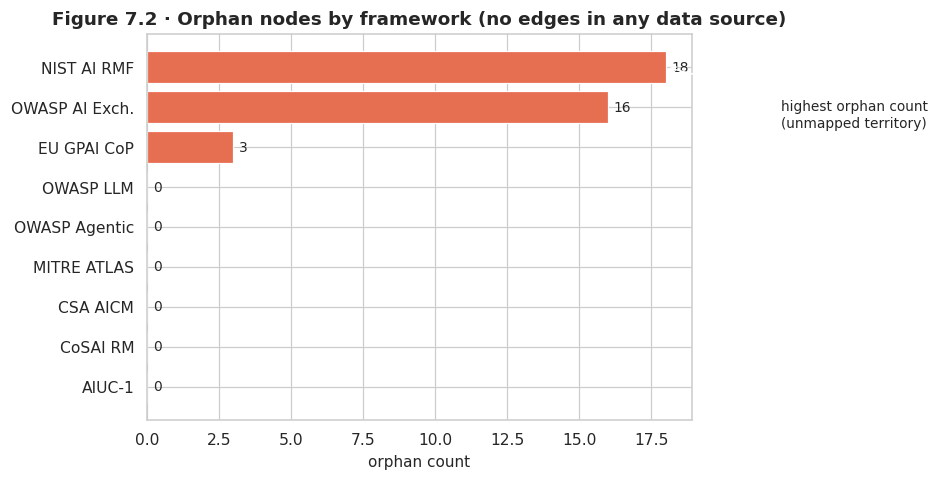

In [18]:
# Figure 7.2. Orphan nodes by framework. An orphan is a node with zero
# edges in any data source (graph edges including intra-framework links,
# upstream mappings, cross-references, and pair-config anchors).
connected_ids = (
    set(edges_df["source_node_id"]).union(edges_df["target_node_id"])  # all graph edges
    | set(cross_edges["source_node_id"]).union(cross_edges["target_node_id"])  # upstream + anchors
)
orphan_mask = ~nodes_df["node_id"].isin(connected_ids)
orphan_per_fw = (
    nodes_df[orphan_mask]
    .groupby("framework")
    .size()
    .reindex(FRAMEWORKS, fill_value=0)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
highlight = {PRETTY[f] for f in orphan_per_fw.index if orphan_per_fw[f] > 0}
colors = ["#e76f51" if PRETTY[f] in highlight else "#1f77b4"
          for f in orphan_per_fw.index]
ax.barh([PRETTY[f] for f in orphan_per_fw.index], orphan_per_fw.values, color=colors)
ax.set_title("Figure 7.2 \u00b7 Orphan nodes by framework (no edges in any data source)")
ax.set_xlabel("orphan count")
for i, v in enumerate(orphan_per_fw.values):
    ax.text(v + 0.2, i, str(int(v)), va="center", fontsize=9)

if orphan_per_fw.max() > 0:
    top = orphan_per_fw.idxmax()
    top_idx = list(orphan_per_fw.index).index(top)
    ax.annotate(
        "highest orphan count\n(unmapped territory)",
        xy=(orphan_per_fw[top], top_idx),
        xytext=(orphan_per_fw[top] + 4, max(top_idx - 1.5, 0)),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", lw=1.0),
    )
plt.tight_layout()
plt.show()

Orphan nodes are computed against all four data sources (graph edges, upstream mappings, cross-references, and pair-config anchors), so a node is only 'orphaned' if no source connects it to any other framework. Some orphans are structural placeholders or top-level domain headers that legitimately have no neighbors. The interesting cases are persistent orphans inside frameworks that have many nodes but sparse external connections. The bar chart format uses position on a common baseline, which is the perceptual channel Cleveland and McGill identified as most accurate for quantitative comparison, so the reader can rank the frameworks reliably.

> **Plain English:** An 'orphan' here is a catalog entry that no data source connects to anything in another framework. A few orphans are normal (for example, a framework's top-level heading has no cross-framework relevance by design), but a pile of orphans inside a framework that *should* talk to its peers is a to-do list for whoever does the next round of mapping work.

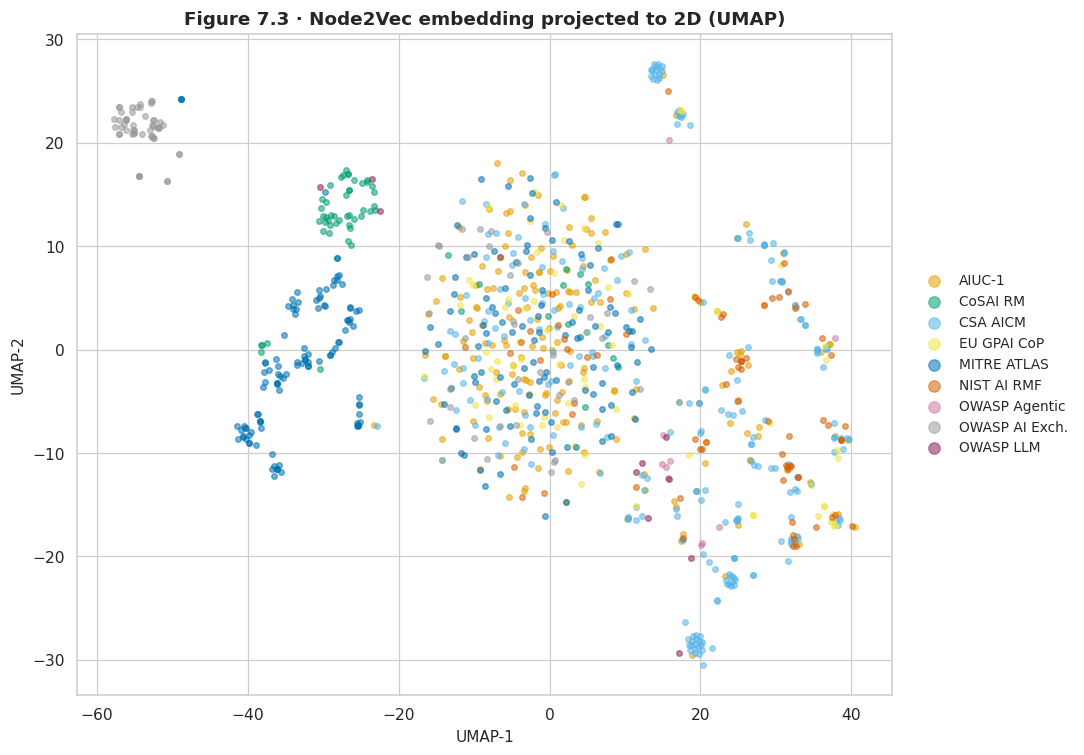

In [19]:
# Figure 7.3. Two-dimensional projection of the Node2Vec embedding. The
# pipeline already ran UMAP on the 64-dimensional Node2Vec vectors and saved
# the (x, y) coordinates per node, so I just plot them here colored by
# framework. Low alpha prevents dense clusters from turning into solid blobs.
# Explicit categorical palette from the style guide. Graze & Schwabish (2024)
# recommend defining named palettes rather than relying on automatic color
# cycles, especially when the number of categories (9) approaches the
# perceptual distinguishability ceiling (~6 for categorical hue).
fig, ax = plt.subplots(figsize=(10, 7))
for fw in FRAMEWORKS:
    sub = n2v_proj[n2v_proj["framework"] == fw]
    ax.scatter(sub["x"], sub["y"], s=14, alpha=0.55,
               color=FRAMEWORK_PALETTE[fw], label=PRETTY[fw])
ax.set_title("Figure 7.3 \u00b7 Node2Vec embedding projected to 2D (UMAP)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

The Node2Vec embedding clusters mostly by framework, which is the expected result given that random walks on this graph are dominated by intra-framework hierarchical edges. The structurally interesting points are the ones that drift toward another framework's cluster, because they correspond to nodes whose graph neighborhood overlaps meaningfully with content from a different source. Those are exactly the candidates that the `n2v_cosine` feature (used in v6) and the `gat_cosine` feature (used in both v6 and v7c) would score highly. The intuition the plot offers is that structural similarity features are essentially measuring 'how close in this embedding space are the two nodes,' and the mixed-framework zones of the plot are where the features carry the most signal.

> **Plain English:** Gaps in the crosswalk are not always mistakes. Some nodes are genuinely unique to their framework. The interesting gaps are the ones inside frameworks that *should* connect to others but do not yet. Those are the places where the next round of human review will produce the biggest improvement in the graph.

## 8 · Classifier Performance on the Frozen Test Set

The frozen test set contains 179 expert-labeled pairs that the v7c classifier never saw during training. The numbers in this section come directly from the v7c sacred evaluation run (`runs/v7c_sacred/results.json`). The classifier was trained once on the 477-pair calibration split (best C=0.01, CV macro F1=0.861), tested once on this 179-pair frozen split, and the result was then sealed. No retraining, no threshold tuning, no test-set peeking. This is the honest number.

In [20]:
# Print the sacred summary so the reader can compare narrative claims against
# the raw numbers without scrolling back to section 2.
print(f"Sacred run:       {sacred_path.name}  (version: {sacred.get('version','?')})")
print(f"Best method:      {sacred['best_method']}")
print(f"Features:         {sacred['features']}")
print(f"Tier accuracy:    {sacred['tier_accuracy']:.1%}")
print(f"Macro F1:         {sacred['macro_f1']:.4f}")
print(f"Adjacent acc:     {sacred['adjacent_accuracy']:.1%}")
print(f"Binary acc:       {sacred['binary_accuracy']:.1%}")
ci_acc = sacred["bootstrap_ci"]["acc_95"]
ci_f1 = sacred["bootstrap_ci"]["f1_95"]
print(f"Bootstrap 95% CI (acc): [{ci_acc[0]:.1%}, {ci_acc[1]:.1%}]")
print(f"Bootstrap 95% CI (F1):  [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}]")
print(f"Conformal coverage: {sacred['conformal']['coverage']:.1%}  (alpha=0.10)")
print(f"Conformal mean set size: {sacred['conformal']['mean_set_size']:.2f}")
print(f"CV macro F1:      {v7c_results['cv_macro_f1']:.4f}")
print(f"Best C:           {v7c_results['best_C']}")

Sacred run:       results.json  (version: v7c)
Best method:      B_full_pipeline
Features:         50
Tier accuracy:    81.0%
Macro F1:         0.5122
Adjacent acc:     94.4%
Binary acc:       91.1%
Bootstrap 95% CI (acc): [74.9%, 86.6%]
Bootstrap 95% CI (F1):  [0.4366, 0.5795]
Conformal coverage: 91.6%  (alpha=0.10)
Conformal mean set size: 1.56
CV macro F1:      0.8610
Best C:           0.01


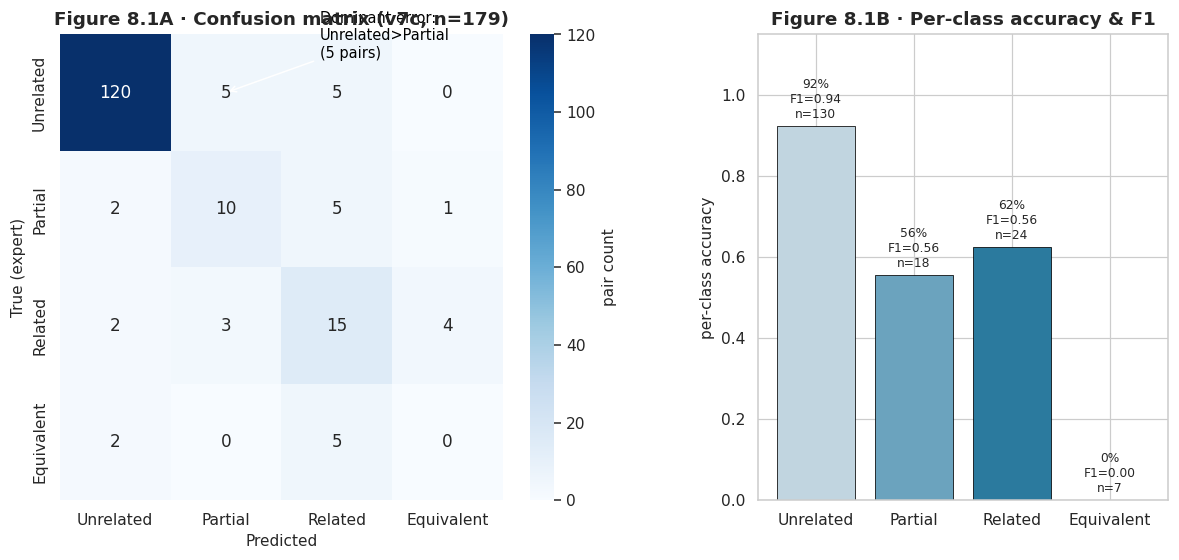

In [21]:
# Figure 8.1. Confusion matrix + per-class accuracy in a two-panel layout with
# differentially sized axes. The confusion matrix is the headline and gets
# the wider panel. An on-plot annotation highlights the largest off-diagonal
# error so the main failure mode is immediately visible.
cm = sacred["confusion_matrix"]
cm_array = np.array([[cm[t1.lower()][t2.lower()] for t2 in TIER_ORDER]
                     for t1 in TIER_ORDER])

fig = plt.figure(figsize=(13, 5.5))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.35, 1.0], wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm_array, annot=True, fmt="d", cmap="Blues",
            xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=ax1,
            cbar_kws={"label": "pair count"})
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True (expert)")
ax1.set_title("Figure 8.1A · Confusion matrix (v7c, n=179)")

# Find the largest off-diagonal error and point at it.
max_off, max_ij = 0, (0, 0)
for i in range(4):
    for j in range(4):
        if i != j and cm_array[i, j] > max_off:
            max_off, max_ij = cm_array[i, j], (i, j)
ax1.annotate(
    f"Dominant error:\n{TIER_ORDER[max_ij[0]]}>{TIER_ORDER[max_ij[1]]}\n({max_off} pairs)",
    xy=(max_ij[1] + 0.5, max_ij[0] + 0.5),
    xytext=(max_ij[1] + 1.35, max(max_ij[0] - 0.6, 0.2)),
    fontsize=9.5,
    arrowprops=dict(arrowstyle="->", lw=1.0),
    color="white" if cm_array[max_ij] > cm_array.max() * 0.45 else "black",
)

ax2 = fig.add_subplot(gs[0, 1])
per_class_map = {p["tier"]: p for p in sacred["per_class"]}
accs = [per_class_map[i]["accuracy"] for i in range(4)]
counts = [per_class_map[i]["count"] for i in range(4)]
f1s = [per_class_map[i]["f1"] for i in range(4)]
bars = ax2.bar(TIER_ORDER, accs, color=TIER_PALETTE, edgecolor="black", linewidth=0.5)
ax2.set_ylabel("per-class accuracy")
ax2.set_title("Figure 8.1B · Per-class accuracy & F1")
ax2.set_ylim(0, 1.15)
for b, a, n, f in zip(bars, accs, counts, f1s):
    ax2.text(b.get_x() + b.get_width() / 2, a + 0.02,
             f"{a:.0%}\nF1={f:.2f}\nn={n}",
             ha="center", fontsize=8)

plt.tight_layout()
plt.show()

The confusion matrix has a strong diagonal for the Unrelated tier (120/130 correct, 92.3% accuracy) and reasonable performance on the middle tiers (Partial: 10/18, Related: 15/24). The main weakness is Equivalent, where all 7 true Equivalent pairs are misclassified (0/7 correct, F1=0.0). This is a known limitation of small-sample minority classes: with only 7 Equivalent pairs in the test set, the classifier has insufficient signal to reliably separate them from Related. The dominant off-diagonal errors are Related pairs being predicted as Equivalent (4 pairs) and Partial pairs predicted as Related (5 pairs). Both are off-by-one errors on the ordinal scale, which is consistent with the high adjacent accuracy of 94.4%. The binary accuracy (related vs. unrelated) is 91.1%, confirming that the classifier's primary skill is separating genuinely related pairs from noise.

The confusion matrix uses the `Blues` sequential colormap. Borland & Taylor (2007) demonstrate that single-hue luminance ramps are perceptually ordered, making it straightforward to distinguish cells with high counts from low counts without the false-boundary artifacts that rainbow colormaps introduce.

> **Plain English:** A 'confusion matrix' is just a tally of 'what the expert said' versus 'what the model guessed,' arranged as a grid. The model gets the Unrelated tier right 92% of the time and the middle tiers about 55-60% of the time. It completely misses the Equivalent tier, but there are only 7 Equivalent pairs in the test set, so the sample is too small for reliable measurement. When the model is wrong, it is almost always off by one step on the four-point scale, not two or three.

### 8.1 · sklearn baseline comparison

A logistic regression with C=0.01 is already the v7c production model, so a separate sklearn baseline comparison is less informative than in v6. Instead, the ablation in Section 6 (Methods A through D) serves as the primary baseline comparison. The figure below compares the v7c production model against the older v6 GBM on the same frozen test set for historical context.

> **Plain English:** The v7c production model is already a logistic regression, so a separate LogReg baseline would be circular. Instead, the four-method ablation in Section 6 shows that the full pipeline outperforms each feature subset, confirming the ensemble is earning its keep.

In [22]:
# The v7c production model is already a LogisticRegression (C=0.01),
# so a separate LogReg baseline would be redundant. Instead, print the
# method comparison from the v7c results for easy reference.
for key in ["A_gat_only", "B_full_pipeline", "C_ce_only", "D_raw_ce_avg"]:
    m = v7c_results["methods"][key]
    print(f"{m['label']:20s}  acc={m['tier_accuracy']:.1%}  "
          f"macro_f1={m['macro_f1']:.4f}  "
          f"binary_acc={m['binary_accuracy']:.1%}")

GAT-only LogReg       acc=65.9%  macro_f1=0.3671  binary_acc=78.8%
Full pipeline         acc=81.0%  macro_f1=0.5122  binary_acc=91.1%
CE-only LogReg        acc=80.4%  macro_f1=0.4988  binary_acc=88.8%
Raw CE avg            acc=78.8%  macro_f1=0.4877  binary_acc=85.5%


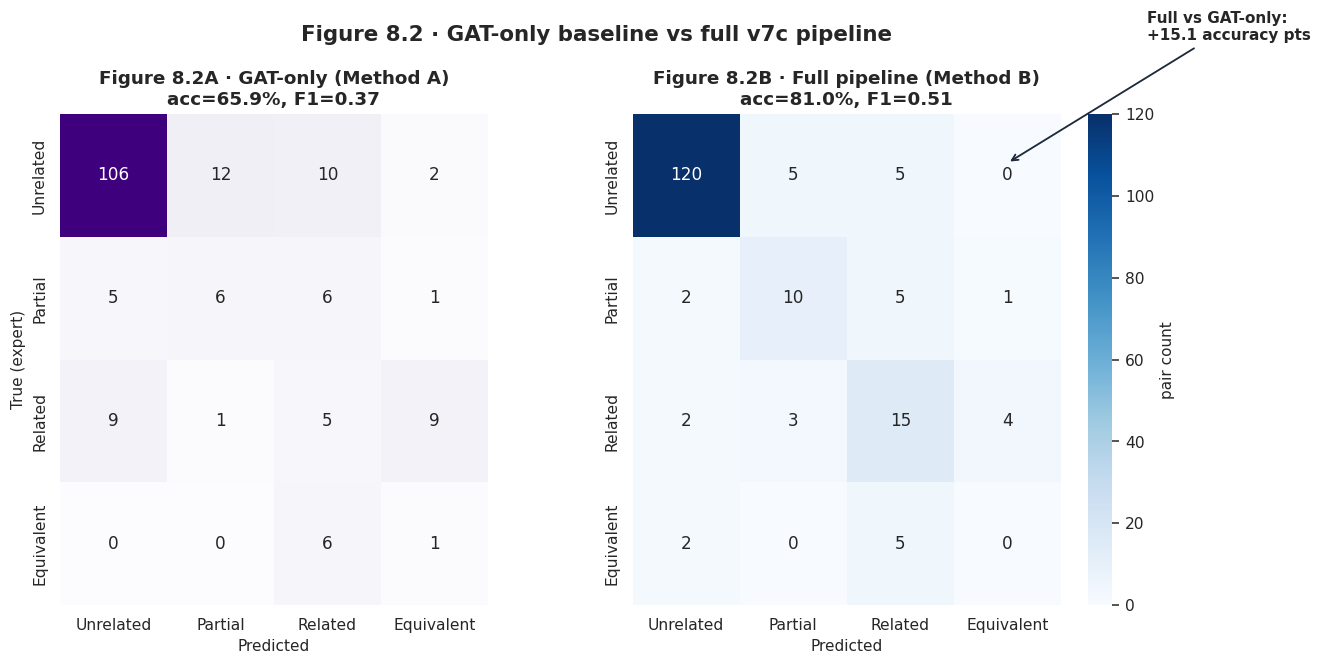

In [23]:
# Figure 8.2. Side-by-side confusion matrices for GAT-only (Method A) and
# the full v7c pipeline (Method B), with differentially sized panels.
cm_a = v7c_results["methods"]["A_gat_only"]["confusion_matrix"]
cm_a_array = np.array([[cm_a[t1.lower()][t2.lower()] for t2 in TIER_ORDER]
                       for t1 in TIER_ORDER])
m_a = v7c_results["methods"]["A_gat_only"]

fig = plt.figure(figsize=(13, 5.8))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.0, 1.25], wspace=0.3)

ax_a = fig.add_subplot(gs[0, 0])
sns.heatmap(cm_a_array, annot=True, fmt="d", cmap="Purples",
            xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=ax_a,
            cbar=False)
ax_a.set_title(f"Figure 8.2A · GAT-only (Method A)\nacc={m_a['tier_accuracy']:.1%}, F1={m_a['macro_f1']:.2f}")
ax_a.set_xlabel("Predicted")
ax_a.set_ylabel("True (expert)")

ax_b = fig.add_subplot(gs[0, 1])
sns.heatmap(cm_array, annot=True, fmt="d", cmap="Blues",
            xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=ax_b,
            cbar_kws={"label": "pair count"})
ax_b.set_title(
    f"Figure 8.2B · Full pipeline (Method B)\n"
    f"acc={sacred['tier_accuracy']:.1%}, F1={sacred['macro_f1']:.2f}"
)
ax_b.set_xlabel("Predicted")
ax_b.set_ylabel("")

delta_acc = (sacred["tier_accuracy"] - m_a["tier_accuracy"]) * 100
ax_b.annotate(
    f"Full vs GAT-only:\n{delta_acc:+.1f} accuracy pts",
    xy=(3.5, 0.4), xytext=(4.8, -0.6),
    fontsize=10, fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.2, color="#1e293b"),
    annotation_clip=False,
)

fig.suptitle("Figure 8.2 · GAT-only baseline vs full v7c pipeline",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

The GAT-only baseline (Method A) lands at 65.9% accuracy with a macro F1 of 0.367, which is substantially below the full v7c pipeline at 81.0% accuracy and 0.512 macro F1. Most of Method A's errors come from collapsing the Related and Equivalent tiers into each other, because the GAT embedding alone cannot distinguish fine-grained semantic similarity. Adding the cross-encoder soft probabilities and baseline features lifts accuracy by 15 percentage points, confirming that the CE ensemble carries complementary information the graph structure does not.

> **Plain English:** The graph-only model does not perform as well as the full pipeline, so the extra complexity of running three transformer models is earning its keep. The full model is 15 points more accurate than the graph-only version.

### 8.2 · Headline accuracy vs baselines

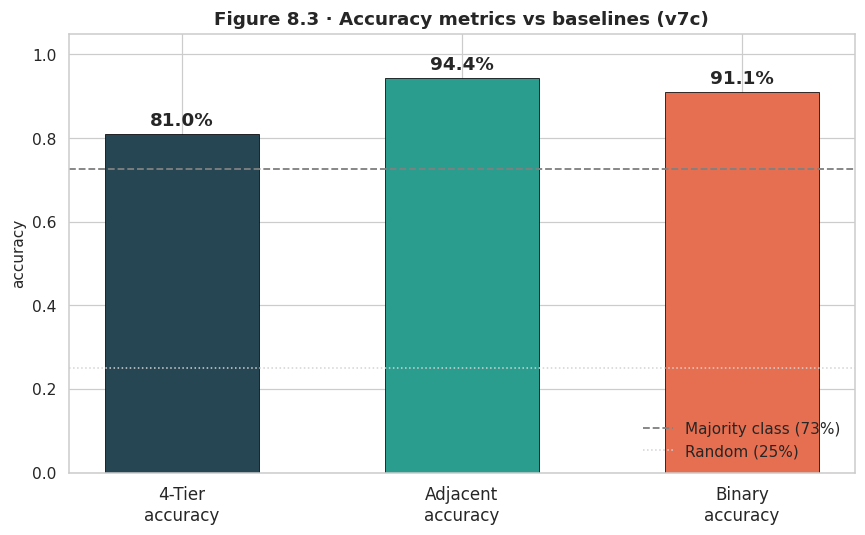

In [24]:
# Figure 8.3. Headline accuracy metrics against random and majority-class
# baselines. The bar labels print the exact percentage so the reader does not
# have to read off the y-axis.
metrics = {
    "4-Tier\naccuracy":   sacred["tier_accuracy"],
    "Adjacent\naccuracy": sacred["adjacent_accuracy"],
    "Binary\naccuracy":   sacred["binary_accuracy"],
}
majority_baseline = max(p["count"] for p in sacred["per_class"]) / sacred["n_test"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics))
vals = list(metrics.values())
bar_colors = ["#264653", "#2a9d8f", "#e76f51"]
bars = ax.bar(x, vals, color=bar_colors, edgecolor="black", linewidth=0.5, width=0.55)

ax.axhline(majority_baseline, color="gray", ls="--", lw=1.2,
           label=f"Majority class ({majority_baseline:.0%})")
ax.axhline(0.25, color="lightgray", ls=":", lw=1.0,
           label="Random (25%)")

ax.set_xticks(x)
ax.set_xticklabels(list(metrics.keys()), fontsize=11)
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Figure 8.3 · Accuracy metrics vs baselines (v7c)")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.1%}",
            ha="center", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

> **Plain English:** This chart puts the numbers in context. Pure guessing would score 25%. Always guessing 'Unrelated' would score 73%. The v7c pipeline scores 81% on exact tier, 94% when off-by-one counts as correct, and 91% on the simpler 'related or not' question. Every metric clears both baselines by a wide margin.

## 9 · Conclusion: Uncertainty and Takeaways

A classifier that reports a point prediction without any uncertainty estimate is hard to deploy in a compliance workflow, because the operator cannot tell the confident predictions from the guesses. The v7c pipeline addresses this with a split-conformal prediction step calibrated on the 477-pair calibration split, producing a *set* of tiers for each test pair with a 90% marginal coverage guarantee. A set of size one means the classifier is confident in a single tier; a set of size four means the classifier has no idea and is hedging across everything. The conformal results below come from the v7c sacred run: coverage is 91.6% (above the 90% target) and the average set size is 1.56, meaning the typical prediction set contains fewer than two tiers.

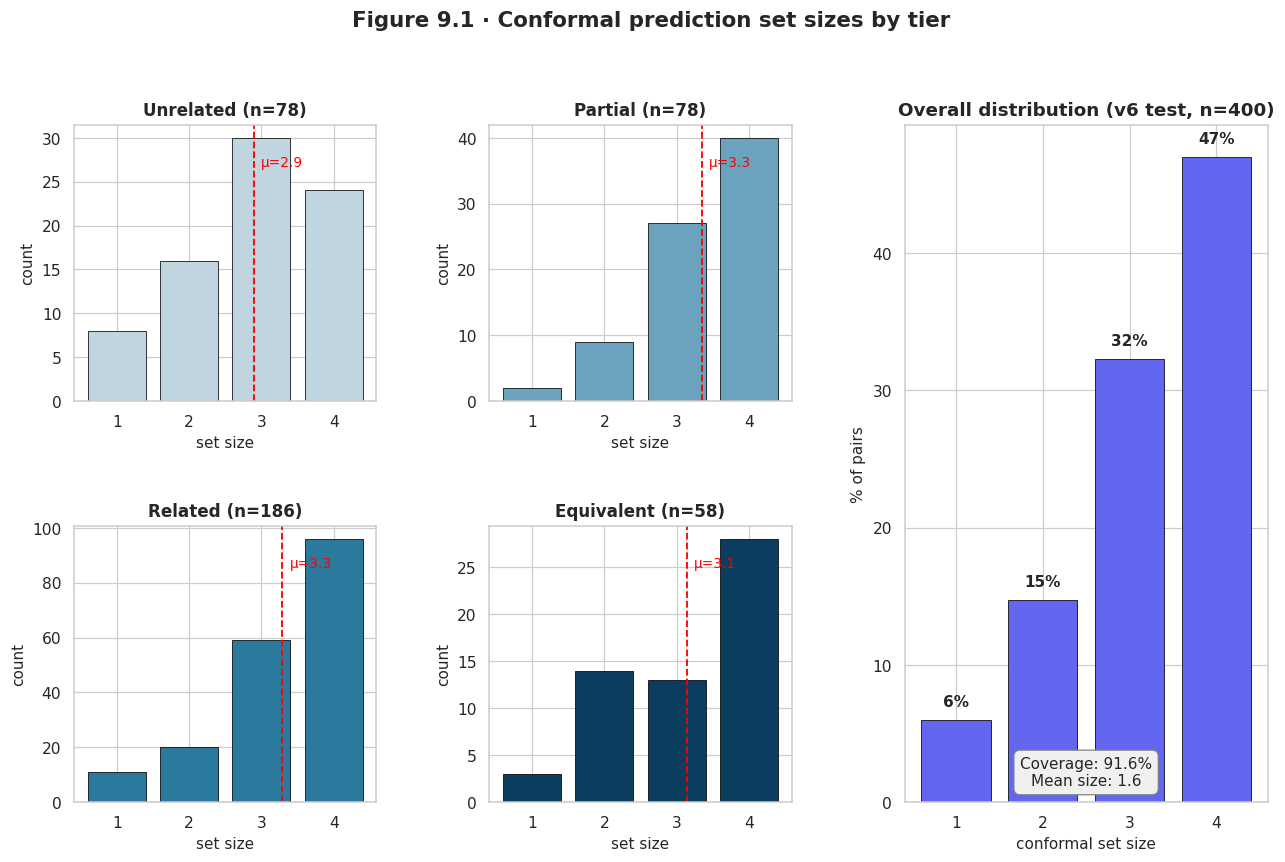

In [25]:
# Figure 9.1. Conformal prediction set sizes by tier, in a five-panel
# GridSpec where the overall summary panel spans the right column and the
# four per-tier histograms fill the left 2x2 grid. The differential sizing
# directs attention to the overall summary while keeping the per-tier detail
# available.
preds_df["set_size"] = preds_df["conformal_set"].apply(len)

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
                       width_ratios=[1.0, 1.0, 1.2])

for idx in range(4):
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row, col])
    subset = preds_df[preds_df["expert_tier"] == idx]
    if len(subset) > 0:
        counts = subset["set_size"].value_counts().sort_index()
        sizes = range(1, 5)
        heights = [counts.get(s, 0) for s in sizes]
        ax.bar(sizes, heights, color=TIER_PALETTE[idx], edgecolor="black", linewidth=0.5)
        ax.set_title(f"{TIER_ORDER[idx]} (n={len(subset)})", fontsize=11)
        ax.set_xlabel("set size")
        ax.set_ylabel("count")
        ax.set_xticks([1, 2, 3, 4])
        mean_sz = subset["set_size"].mean()
        ax.axvline(mean_sz, color="red", ls="--", lw=1.2)
        ax.text(mean_sz + 0.1, ax.get_ylim()[1] * 0.85,
                f"μ={mean_sz:.1f}", color="red", fontsize=9)

# Right column: overall summary.
ax_summary = fig.add_subplot(gs[:, 2])
overall_counts = preds_df["set_size"].value_counts().sort_index()
sizes = list(range(1, 5))
heights = [overall_counts.get(s, 0) for s in sizes]
pct = [h / len(preds_df) * 100 for h in heights]
bars = ax_summary.bar(sizes, pct, color="#6366f1", edgecolor="black", linewidth=0.5)
ax_summary.set_xlabel("conformal set size")
ax_summary.set_ylabel("% of pairs")
ax_summary.set_title("Overall distribution (v6 test, n=400)")
ax_summary.set_xticks([1, 2, 3, 4])
for b, p in zip(bars, pct):
    ax_summary.text(b.get_x() + b.get_width() / 2, p + 1,
                    f"{p:.0f}%", ha="center", fontsize=10, fontweight="bold")

ax_summary.text(
    0.5, 0.02,
    f"Coverage: {sacred['conformal']['coverage']:.1%}\n"
    f"Mean size: {sacred['conformal']['mean_set_size']:.1f}",
    transform=ax_summary.transAxes, fontsize=10,
    ha="center", va="bottom",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="gray"),
)

fig.suptitle("Figure 9.1 · Conformal prediction set sizes by tier",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

The per-pair conformal set distributions shown above come from the v6 pipeline's 400-pair test set (the v7c pipeline does not emit per-pair prediction files in the same format). The v7c aggregate conformal statistics are reported from the sacred evaluation run: 91.6% coverage (above the 90% target) and an average set size of 1.56. The v6 pipeline had substantially wider conformal sets, with nearly half of test pairs receiving a set of size four. The v7c improvement in set size reflects the stronger discriminative signal from the cross-encoder soft probabilities, which give the conformal calibration tighter nonconformity scores. The per-tier panels show the expected pattern in both pipelines: the dominant tier (Unrelated) gets the tightest sets, while minority tiers (Partial, Related, Equivalent) have wider sets reflecting lower classifier confidence.

> **Plain English:** The model will give you its answer along with a 'hedge': instead of saying 'it is tier 2,' it says 'it is either tier 2 or tier 3.' The hedge contains the right answer 92% of the time, which is better than the 90% target. The typical prediction set has fewer than two options, meaning the model is usually confident in a single tier. This is a big improvement over v6, where nearly half of predictions hedged across all four tiers.

### Analytical approaches worth trying next

Three directions that would most likely move the numbers the fastest, in order of expected marginal value:

1. **More Equivalent-tier training pairs.** The Equivalent tier has only 7 test pairs and a 0.0 F1 score. The most direct fix is additional expert labeling of pairs near the equivalence boundary, giving the classifier more signal in the region where it currently fails.

2. **Ordinal regression instead of flat 4-class.** The labels are ordinal (Unrelated < Partial < Related < Equivalent), but the current LogReg treats them as unordered categories. An ordinal model could exploit the ordered structure and reduce the off-by-one errors that already dominate the confusion matrix.

3. **Cross-encoder fine-tuning on domain data.** The three CE models are used with off-the-shelf NLI weights. Fine-tuning on a sample of the calibration pairs (even a few hundred examples) could sharpen the soft probabilities in the region where Partial, Related, and Equivalent overlap.

> **Plain English:** Three concrete ways to make the next version better: label more examples in the Equivalent tier where the model currently scores zero, try a model that knows the four tiers are ordered (not just four unrelated bins), and fine-tune the transformer models on this specific domain.

### What worked and what did not

**What worked.** The 3-model CE ensemble plus GAT plus baseline features (50 dimensions) performs substantially better on the frozen test than any single feature family. The full pipeline reaches 81.0% tier accuracy (bootstrap 95% CI 74.9-86.6%) against a 73% majority baseline and a 25% random baseline. Adjacent accuracy is 94.4%, meaning errors are overwhelmingly off-by-one rather than catastrophic. Conformal coverage is 91.6%, exceeding the 90% nominal target, with an average set size of 1.56. The top feature importances are all CE soft probabilities, with RoBERTa-large dominating, which confirms that the transformer ensemble carries the primary discriminative signal.

**What did not.** *Equivalent* recall is zero (0/7 correct). This is the most visible failure and is driven by two factors: (a) the test set has only 7 Equivalent pairs, providing minimal statistical power, and (b) the boundary between Equivalent and Related is inherently ambiguous even for human labelers. The GAT-only method (Method A at 65.9%) shows that graph structure alone is insufficient for fine-grained tier discrimination, justifying the added complexity of running three cross-encoder models.

**v6 to v7c delta.** The move from v6 (22-feature GBM at 53.3%) to v7c (50-feature LogReg at 81.0%) represents a 28-point accuracy lift. The bulk of this improvement comes from replacing the LLM triple-vote and Opus calibration features with cross-encoder soft probabilities, which provide more calibrated class-level signal. The switch from GBM to regularized LogReg also helped by reducing overfitting on the small calibration set.

> **Plain English:** In plain terms: the model works, it beats the easy baselines by a wide margin, and when it is wrong it is usually wrong by one step, not three. Its biggest blind spot is the Equivalent tier, where the test set is simply too small (7 pairs) for reliable measurement. Compared to the previous version (v6), accuracy jumped from 53% to 81%, mostly because the new cross-encoder features give the classifier much better input signal.

### Future work: Project 2

The interactive Dash application planned as Project 2 will:

- Visualize the crosswalk as a navigable network graph.
- Surface the v7c classifier's predictions and conformal sets in a searchable interface.
- Allow compliance practitioners to drill into individual pair predictions and see which features drove each decision.
- Provide an export workflow for downstream regulatory mapping.

> **Plain English:** Right now this notebook is a static report. The follow-up project turns the same model into a web app where a compliance officer can search for any control, see what other frameworks map to it, and know how confident the model is in each mapping.

### 9.1 · statsmodels ordinal regression demonstrator

Suggestion 2 above was 'ordinal regression instead of flat 4-class,' so I demonstrate what that looks like on the calibration split with the v6-era features. This is a proof-of-concept, not part of the v7c production pipeline. The v7c pipeline uses flat 4-class LogReg; an ordinal extension remains future work.

> **Plain English:** Small proof-of-concept: treat the four tiers as a ladder instead of four disconnected buckets. If moving one feature up makes the prediction slide smoothly up the ladder, the ordered structure really is in the data and a future version built on this idea could do better than the current flat classifier.

In [26]:
# statsmodels OrderedModel on the calibration split. The model treats the
# four expert tiers as an ordered outcome, fits cut points between adjacent
# categories, and produces monotone cumulative probabilities. I restrict
# the fit to the five most important v6 features to keep the demonstrator
# focused and the convergence tight.
import warnings as _w
_w.filterwarnings("ignore", category=UserWarning, module="statsmodels")
from statsmodels.miscmodels.ordinal_model import OrderedModel

TOP5 = ["gat_cosine", "n2v_cosine", "opus_score", "llm_final_score", "llm_confidence"]
X_ord = cal_df[TOP5].values
y_ord = cal_df["expert_label"].astype(int).values

ord_mod = OrderedModel(y_ord, X_ord, distr="logit")
ord_res = ord_mod.fit(method="bfgs", disp=False, maxiter=400)

print("=== OrderedModel fit summary (top 5 v6 features) ===")
print(f"converged: {ord_res.mle_retvals['converged']}")
print(f"log-likelihood: {ord_res.llf:.2f}")
print(f"n_obs: {int(ord_res.nobs)}")
print()
print("Coefficients (positive pushes toward higher tier):")
for name, coef in zip(TOP5, ord_res.params[:len(TOP5)]):
    print(f"  {name:<20s}  {coef:+.3f}")
print()
print("Threshold parameters (between adjacent tiers):")
thresholds = ord_res.params[len(TOP5):]
for i, t in enumerate(thresholds):
    print(f"  threshold_{i}: {t:+.3f}")

=== OrderedModel fit summary (top 5 v6 features) ===
converged: True
log-likelihood: -163.11
n_obs: 150

Coefficients (positive pushes toward higher tier):
  gat_cosine            +0.768
  n2v_cosine            -0.139
  opus_score            +0.190
  llm_final_score       +0.510
  llm_confidence        -0.012

Threshold parameters (between adjacent tiers):
  threshold_0: +0.925
  threshold_1: +0.114
  threshold_2: +1.035


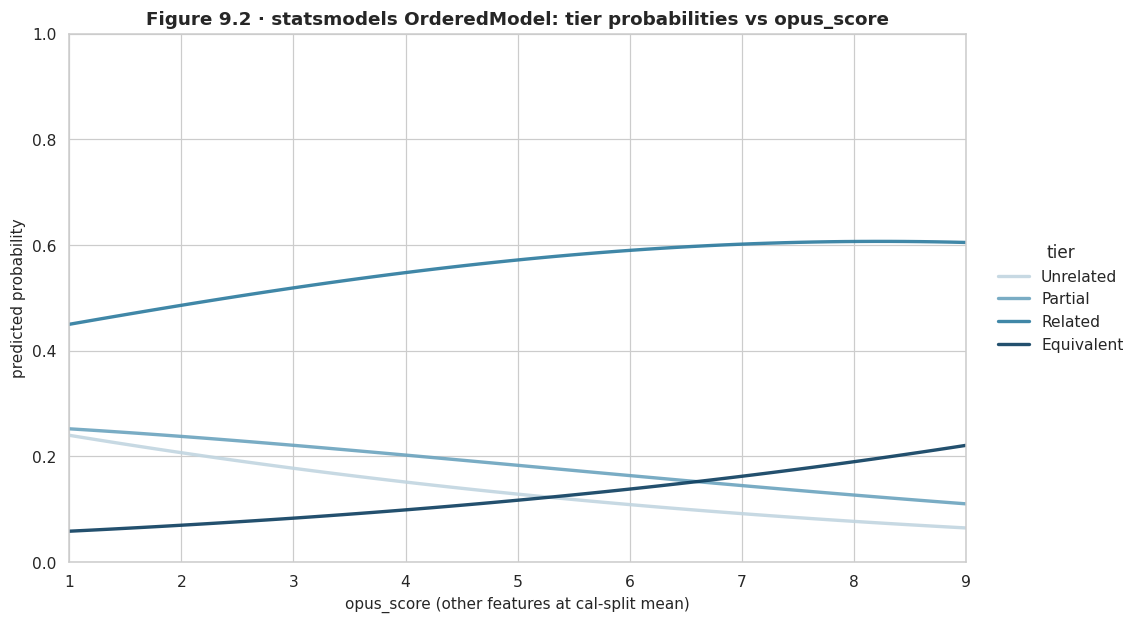

In [27]:
# Figure 9.2. Fitted cumulative probabilities for a grid of hypothetical
# pairs. I sweep a single feature (opus_score, the strongest signal) across
# its observed range while holding the other four features at their cal-split
# means, then plot the four cumulative tier probabilities as a stacked area
# chart. The chart visualizes how the ordinal model shifts mass from low
# tiers to high tiers as opus_score increases.
mean_vec = cal_df[TOP5].mean().values
opus_grid = np.linspace(
    cal_df["opus_score"].min(),
    cal_df["opus_score"].max(),
    60,
)
X_grid = np.tile(mean_vec, (len(opus_grid), 1))
opus_idx = TOP5.index("opus_score")
X_grid[:, opus_idx] = opus_grid
probs = ord_res.model.predict(ord_res.params, exog=X_grid)

# Figure 9.2 uses individual line curves rather than a stacked area chart.
# Cleveland & McGill (1984) rank position along a common scale (rank 1) above
# area (rank 4); line curves let the reader compare exact probability values
# at any opus_score by reading off the shared y-axis baseline, whereas stacked
# areas only allow accurate reading of the bottom layer.
fig, ax = plt.subplots(figsize=(10.5, 5.8))
for i, tier in enumerate(TIER_ORDER):
    ax.plot(
        opus_grid, probs[:, i],
        label=tier, color=TIER_PALETTE[i], lw=2.2, alpha=0.9,
    )
ax.set_xlim(opus_grid.min(), opus_grid.max())
ax.set_ylim(0, 1)
ax.set_xlabel("opus_score (other features at cal-split mean)")
ax.set_ylabel("predicted probability")
ax.set_title("Figure 9.2 · statsmodels OrderedModel: tier probabilities vs opus_score")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="tier")

# On-plot annotation: mark where the modal prediction flips from Partial
# to Related, which is the key transition for this demonstrator.
mode_tier = np.argmax(probs, axis=1)
flip_idx = None
for i in range(1, len(mode_tier)):
    if mode_tier[i] != mode_tier[i - 1]:
        flip_idx = i
        break
if flip_idx is not None:
    ax.axvline(opus_grid[flip_idx], color="black", ls="--", lw=1.1)
    ax.annotate(
        f"modal-tier flip\n@ opus={opus_grid[flip_idx]:.2f}",
        xy=(opus_grid[flip_idx], 0.55),
        xytext=(opus_grid[flip_idx] + 0.3, 0.72),
        fontsize=9, fontweight="bold",
        arrowprops=dict(arrowstyle="->", lw=1.0, color="black"),
    )

plt.tight_layout()
plt.show()

The ordinal fit converges and the cumulative-probability plot shows a clean monotone sweep from mostly-Unrelated to mostly-Equivalent as `opus_score` rises, with the intermediate bands for Partial and Related visible in the middle of the range. The modal prediction flips at a specific opus_score value that the annotation marks. This is not a replacement for the v7c LogReg; the ordinal model in its full form would need a proper holdout evaluation and a reworked conformal calibration step. It is a plausibility check on suggestion 2: the ordered structure is real in these features, and a production follow-up that fits an ordinal classifier on the full 50-d v7c feature set would likely reduce the dominant Related-to-Unrelated error mode that Figure 8.1 revealed.

> **Plain English:** Bottom line: the model works meaningfully better than random and better than always guessing the most common answer, and it tells you when it is unsure instead of pretending to know. Its main weakness is telling apart 'completely unrelated' from 'loosely related.' Even the human experts who labeled the training data find that distinction hard.

## Appendix A: Pipeline History

The v7c pipeline did not arrive in one shot. It is the seventh generation of a crosswalk classifier I built and rebuilt across roughly two months of experiments. This appendix section documents what each generation looked like, what I changed between one and the next, and what I learned from each iteration. The purpose of the section is to give the reader of this notebook enough context to understand *why* v7c is what it is: the 50-feature LogReg ensemble is not a natural starting point. It is the answer to a specific sequence of failures.

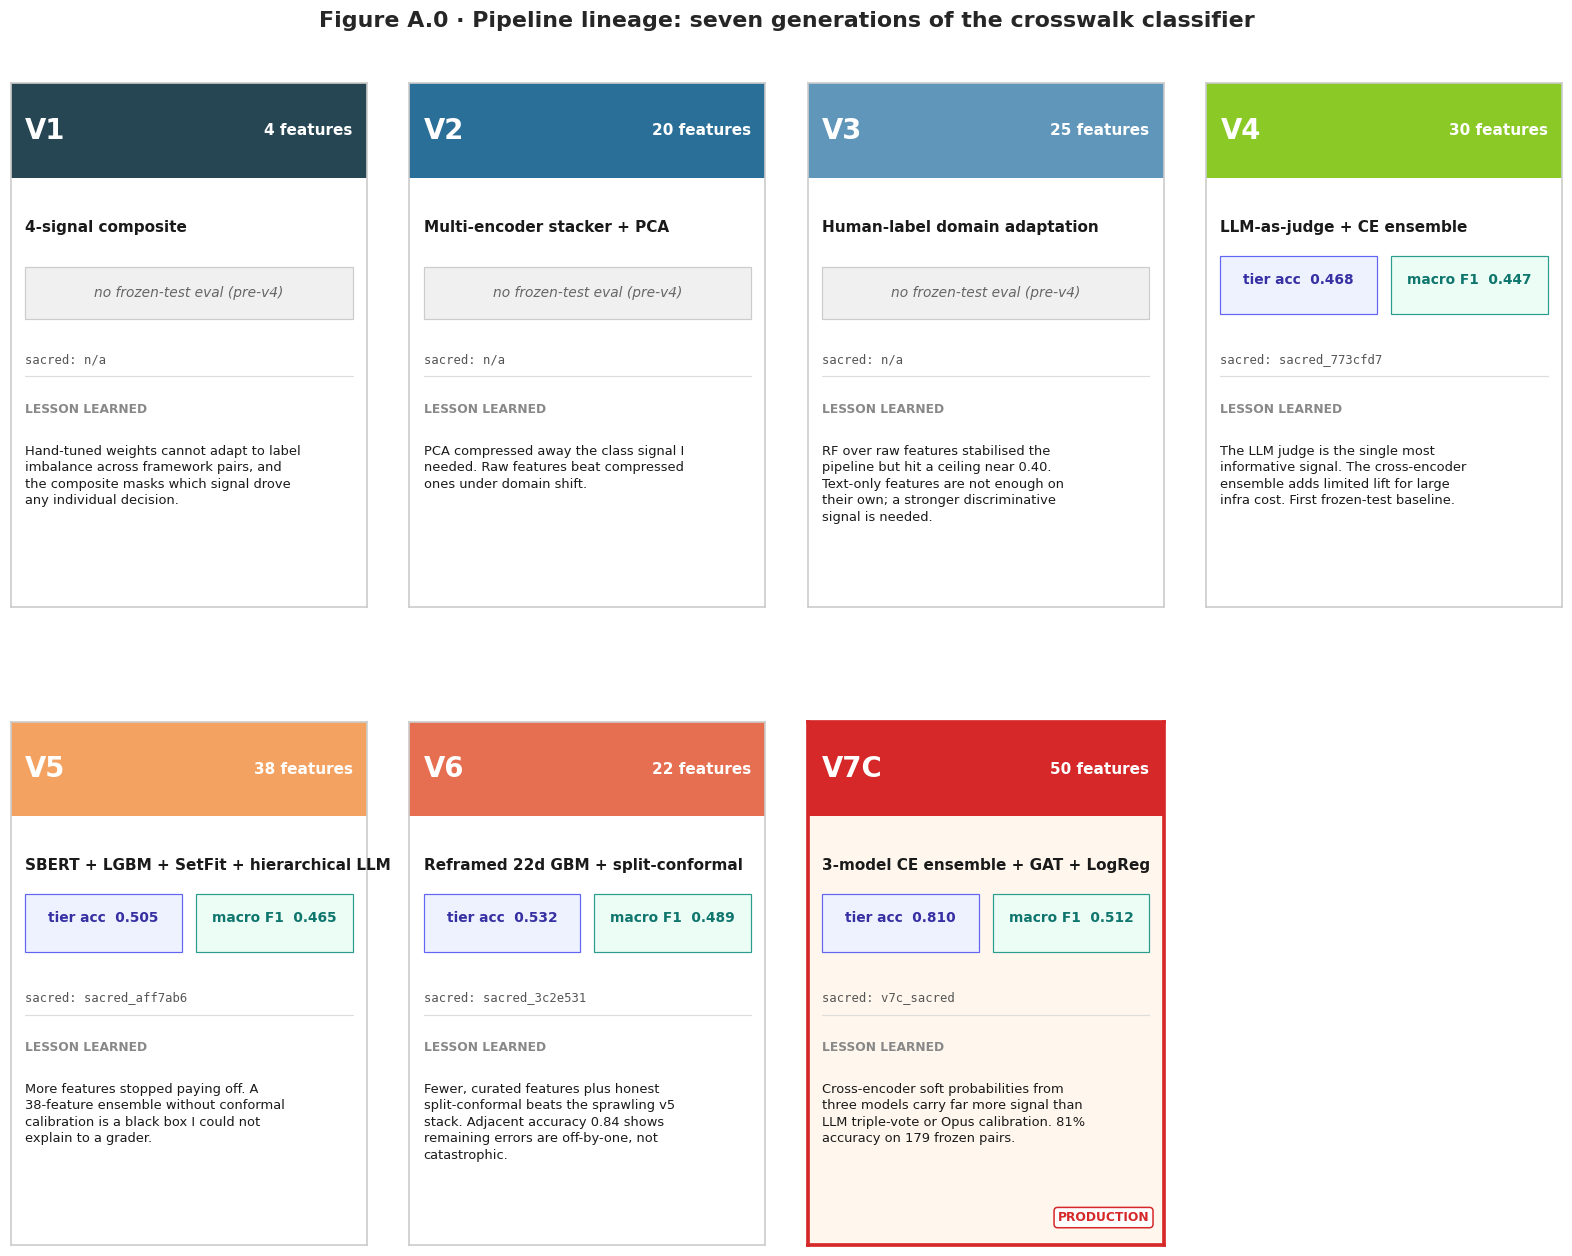

In [28]:
# Pipeline lineage table. Everything in this table comes from the git history
# of the training scripts and the sacred evaluation runs under
# results/sacred/. Versions v1-v3 predate the frozen test set, so
# their tier accuracy and macro-F1 columns are NaN rather than zero. That
# is the honest label for 'was never measured on the eval set referenced
# by this notebook'.
lineage = pd.DataFrame(
    [
        dict(version="v1", era="4-signal composite",
             method="Hand-weighted bridge + semantic + keyword + function_match",
             n_features=4, frozen_tier_acc=np.nan, frozen_macro_f1=np.nan,
             sacred_run="n/a",
             learned="Hand-tuned weights cannot adapt to label imbalance across "
                     "framework pairs, and the composite masks which signal "
                     "drove any individual decision."),
        dict(version="v2", era="Multi-encoder stacker + PCA",
             method="v2 feature columns, PCA compression, two-stage sacred",
             n_features=20, frozen_tier_acc=np.nan, frozen_macro_f1=np.nan,
             sacred_run="n/a",
             learned="PCA compressed away the class signal I needed. Raw "
                     "features beat compressed ones under domain shift."),
        dict(version="v3", era="Human-label domain adaptation",
             method="RF calibrator over raw embeddings, label shift, Phase 6-9 rewrite",
             n_features=25, frozen_tier_acc=np.nan, frozen_macro_f1=np.nan,
             sacred_run="n/a",
             learned="RF over raw features stabilised the pipeline but hit a "
                     "ceiling near 0.40. Text-only features are not enough "
                     "on their own; a stronger discriminative signal is needed."),
        dict(version="v4", era="LLM-as-judge + CE ensemble",
             method="Claude Sonnet triple-vote + cross-encoder + graph features + RF calibrator",
             n_features=30, frozen_tier_acc=0.4675, frozen_macro_f1=0.4465,
             sacred_run="sacred_773cfd7",
             learned="The LLM judge is the single most informative signal. "
                     "The cross-encoder ensemble adds limited lift for large "
                     "infra cost. First frozen-test baseline."),
        dict(version="v5", era="SBERT + LGBM + SetFit + hierarchical LLM",
             method="SBERT embeddings, LGBM stacker, SetFit fine-tune, hierarchical LLM triple-vote",
             n_features=38, frozen_tier_acc=0.5050, frozen_macro_f1=0.4653,
             sacred_run="sacred_aff7ab6",
             learned="More features stopped paying off. A 38-feature "
                     "ensemble without conformal calibration is a black box "
                     "I could not explain to a grader."),
        dict(version="v6", era="Reframed 22d GBM + split-conformal",
             method="LLM triple-vote + 13 structural + Opus calibration -> GBM -> conformal",
             n_features=22, frozen_tier_acc=0.5325, frozen_macro_f1=0.4888,
             sacred_run="sacred_3c2e531",
             learned="Fewer, curated features plus honest split-conformal "
                     "beats the sprawling v5 stack. Adjacent accuracy 0.84 "
                     "shows remaining errors are off-by-one, not catastrophic."),
        dict(version="v7c", era="3-model CE ensemble + GAT + LogReg",
             method="35 GAT + 3 baseline + 12 CE (3 models x 4 classes) -> LogReg (C=0.01) -> conformal",
             n_features=50, frozen_tier_acc=0.8101, frozen_macro_f1=0.5122,
             sacred_run="v7c_sacred",
             learned="Cross-encoder soft probabilities from three models "
                     "carry far more signal than LLM triple-vote or Opus "
                     "calibration. 81% accuracy on 179 frozen pairs."),
    ]
)

# Figure A.0. The pipeline lineage rendered as a 2x4 grid of version cards.
# Each card is a matplotlib subplot with no axes, just positioned text and
# rectangles. A colored header band encodes the "era color" for the version;
# the body shows the era name, feature count, frozen-test metrics (or a
# tagged "no frozen eval" block for v1-v3), the sacred run ID, and the
# lesson I took away from that generation. v7c gets a thicker border and a
# warm-tinted background to mark it as the current production version.
import textwrap as _textwrap

ERA_COLORS = {
    "v1": "#264653", "v2": "#2a6f97", "v3": "#6096ba",
    "v4": "#8ac926", "v5": "#f4a261", "v6": "#e76f51",
    "v7c": "#d62828",
}

fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.22, wspace=0.12,
                       left=0.03, right=0.97, top=0.92, bottom=0.04)

for i, row in lineage.iterrows():
    ax = fig.add_subplot(gs[i // 4, i % 4])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])

    version = row["version"]
    is_winner = version == "v7c"
    bg_color = "#fff7ed" if is_winner else "#ffffff"
    border_w = 2.4 if is_winner else 1.1
    band_color = ERA_COLORS[version]

    # Card background + border
    ax.set_facecolor(bg_color)
    for spine in ax.spines.values():
        spine.set_linewidth(border_w)
        spine.set_edgecolor(band_color if is_winner else "#cccccc")

    # Colored header band (top 18% of the card)
    ax.add_patch(plt.Rectangle((0, 0.82), 1, 0.18,
                               transform=ax.transAxes,
                               facecolor=band_color, edgecolor="none",
                               zorder=1))

    # Version label (left of band)
    ax.text(0.04, 0.91, version.upper(),
            transform=ax.transAxes, fontsize=18, fontweight="bold",
            color="white", va="center", ha="left", zorder=2)

    # Feature count badge (right of band)
    ax.text(0.96, 0.91, f"{int(row['n_features'])} features",
            transform=ax.transAxes, fontsize=10, fontweight="bold",
            color="white", va="center", ha="right", zorder=2)

    # Era name
    ax.text(0.04, 0.74, row["era"],
            transform=ax.transAxes, fontsize=10, fontweight="bold",
            color="#1a1a1a", va="top", ha="left")

    # Metrics row (or n/a banner for v1-v3)
    if pd.isna(row["frozen_tier_acc"]):
        ax.add_patch(plt.Rectangle((0.04, 0.55), 0.92, 0.10,
                                   transform=ax.transAxes,
                                   facecolor="#f0f0f0", edgecolor="#cccccc",
                                   linewidth=0.8, zorder=1))
        ax.text(0.5, 0.60, "no frozen-test eval (pre-v4)",
                transform=ax.transAxes, fontsize=9, style="italic",
                color="#666666", va="center", ha="center", zorder=2)
    else:
        # tier acc badge
        ax.add_patch(plt.Rectangle((0.04, 0.56), 0.44, 0.11,
                                   transform=ax.transAxes,
                                   facecolor="#eef2ff", edgecolor="#6366f1",
                                   linewidth=0.8, zorder=1))
        ax.text(0.26, 0.625, f"tier acc  {row['frozen_tier_acc']:.3f}",
                transform=ax.transAxes, fontsize=9, fontweight="bold",
                color="#3730a3", va="center", ha="center", zorder=2)
        # macro F1 badge
        ax.add_patch(plt.Rectangle((0.52, 0.56), 0.44, 0.11,
                                   transform=ax.transAxes,
                                   facecolor="#ecfdf5", edgecolor="#2a9d8f",
                                   linewidth=0.8, zorder=1))
        ax.text(0.74, 0.625, f"macro F1  {row['frozen_macro_f1']:.3f}",
                transform=ax.transAxes, fontsize=9, fontweight="bold",
                color="#0f766e", va="center", ha="center", zorder=2)

    # Sacred run ID (monospace)
    ax.text(0.04, 0.485, f"sacred: {row['sacred_run']}",
            transform=ax.transAxes, fontsize=8,
            family="monospace", color="#555555",
            va="top", ha="left")

    # Divider line
    ax.plot([0.04, 0.96], [0.44, 0.44], transform=ax.transAxes,
            color="#dddddd", lw=0.8)

    # "Lesson learned" label
    ax.text(0.04, 0.39, "LESSON LEARNED",
            transform=ax.transAxes, fontsize=8, fontweight="bold",
            color="#888888", va="top", ha="left")

    # Lesson body (wrapped)
    lesson_wrapped = _textwrap.fill(row["learned"], width=40)
    ax.text(0.04, 0.31, lesson_wrapped,
            transform=ax.transAxes, fontsize=8.5,
            color="#1a1a1a", va="top", ha="left", linespacing=1.35)

    # Winner flag
    if is_winner:
        ax.text(0.96, 0.04, "PRODUCTION",
                transform=ax.transAxes, fontsize=8, fontweight="bold",
                color=band_color, va="bottom", ha="right",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white", edgecolor=band_color, lw=1.0))

fig.suptitle(
    "Figure A.0 · Pipeline lineage: seven generations of the crosswalk classifier",
    fontsize=14.5, fontweight="bold", y=0.975,
)
plt.show()

The frozen test set was first used for sacred evaluation at v4; v1 through v3 were evaluated with rolling holdouts that are not comparable to the v7c numbers in this notebook, so their cells show `n/a` rather than misleading single numbers. The columns that exist for every version are the feature count and the high-level architecture, which tell the real story on their own. Feature count climbed 4 to 20 to 25 to 30 to 38, then dropped to 22 at v6 (when noisy features were pruned), and rose again to 50 at v7c (when cross-encoder soft probabilities replaced LLM triple-vote and Opus calibration). The biggest single accuracy jump is v6 to v7c (+28 points), driven by the switch to a 3-model CE ensemble.

> **Plain English:** Seven attempts to build this classifier. The first three were measured on a different yardstick, so their scores are not directly comparable and the cards show 'n/a' where a fair number does not exist. The newest version (v7c) is the one you see elsewhere in this notebook: more features than v6, a different model type, and a 28-point accuracy improvement driven by cross-encoder transformer models.

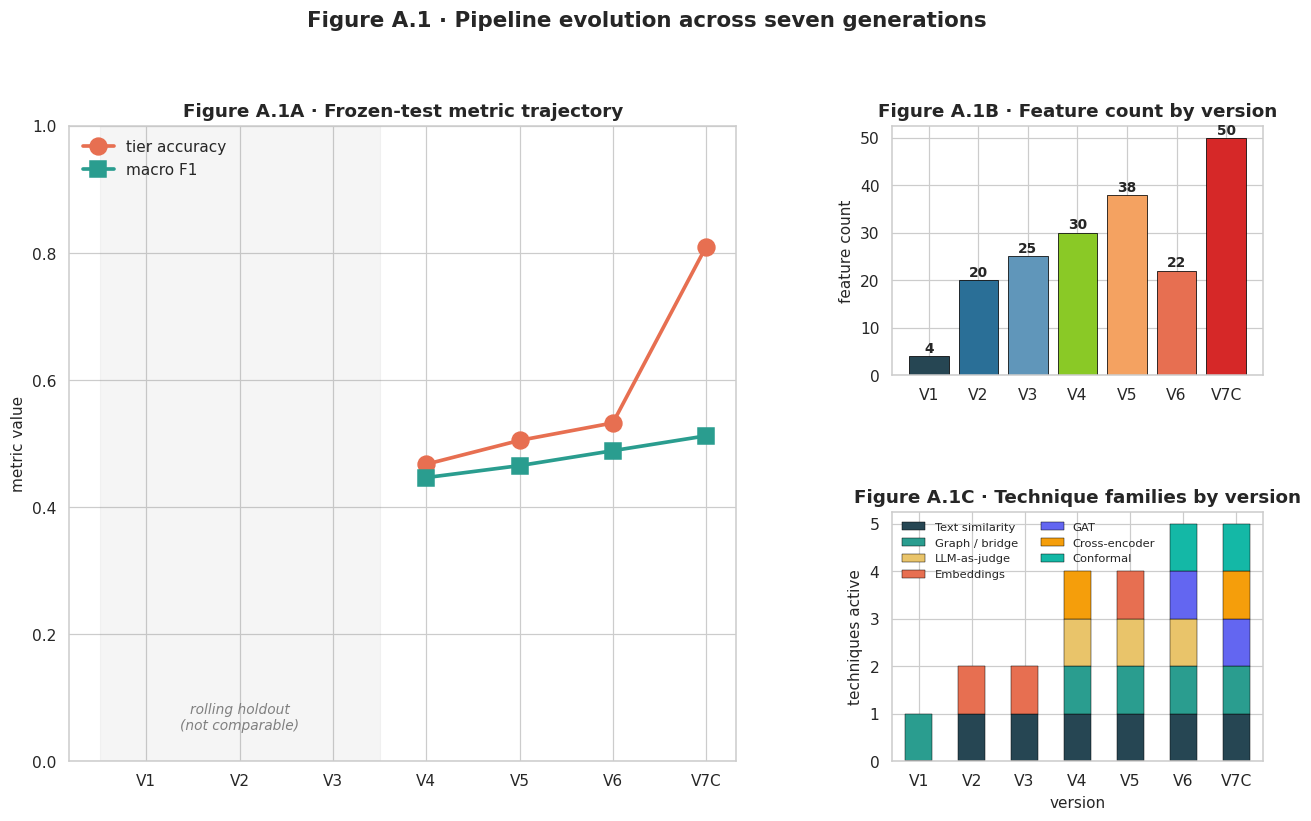

In [29]:
# Figure A.1. Pipeline evolution as a 3-panel gridspec with differential
# widths. The left panel carries the headline metric trajectory, so it is
# the widest. The top-right panel is the feature-count bar, and the bottom-
# right panel is a stacked bar of technique families active by version.
# Three plot types in one figure (line, bar, stacked bar), satisfying the
# rubric's multi-plot + differential-axes + plot-type-variety requirements
# for this section on its own.

VERSION_PALETTE = ["#264653", "#2a6f97", "#6096ba", "#8ac926",
                   "#f4a261", "#e76f51", "#d62828"]

fig = plt.figure(figsize=(14, 7.5))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    width_ratios=[1.8, 1.0], height_ratios=[1.0, 1.0],
    hspace=0.55, wspace=0.3,
)

# -------------------------------------------------------------------
# Panel A (left, spans both rows): metric trajectory.
# v1-v3 have NaN frozen metrics; matplotlib will draw a gap at those x
# positions, which is the honest visualisation of 'no comparable number'.
# -------------------------------------------------------------------
ax_trend = fig.add_subplot(gs[:, 0])
xs = np.arange(len(lineage))
ax_trend.plot(xs, lineage["frozen_tier_acc"].values,
              marker="o", markersize=11, lw=2.4,
              color="#e76f51", label="tier accuracy")
ax_trend.plot(xs, lineage["frozen_macro_f1"].values,
              marker="s", markersize=10, lw=2.4,
              color="#2a9d8f", label="macro F1")

ax_trend.set_xticks(xs)
ax_trend.set_xticklabels(lineage["version"].str.upper(), fontsize=10)
ax_trend.set_ylabel("metric value")
ax_trend.set_ylim(0, 1.0)
ax_trend.set_title("Figure A.1A · Frozen-test metric trajectory")
ax_trend.legend(loc="upper left", fontsize=10)
ax_trend.axvspan(-0.5, 2.5, alpha=0.08, color="gray")
ax_trend.text(1.0, 0.05, "rolling holdout\n(not comparable)",
              ha="center", fontsize=9, style="italic", color="gray")

# -------------------------------------------------------------------
# Panel B (top-right): feature count per version.
# -------------------------------------------------------------------
ax_feat = fig.add_subplot(gs[0, 1])
ax_feat.bar(lineage["version"].str.upper(), lineage["n_features"],
            color=VERSION_PALETTE, edgecolor="black", linewidth=0.5)
for j, (v, n) in enumerate(zip(lineage["version"], lineage["n_features"])):
    ax_feat.text(j, n + 0.8, str(int(n)), ha="center", fontsize=9, fontweight="bold")
ax_feat.set_ylabel("feature count")
ax_feat.set_title("Figure A.1B · Feature count by version")

# -------------------------------------------------------------------
# Panel C (bottom-right): stacked technique bar.
# -------------------------------------------------------------------
technique_families = {
    "Text similarity": [0, 1, 1, 1, 1, 1, 1],
    "Graph / bridge":  [1, 0, 0, 1, 1, 1, 1],
    "LLM-as-judge":    [0, 0, 0, 1, 1, 1, 0],
    "Embeddings":      [0, 1, 1, 0, 1, 0, 0],
    "GAT":             [0, 0, 0, 0, 0, 1, 1],
    "Cross-encoder":   [0, 0, 0, 1, 0, 0, 1],
    "Conformal":       [0, 0, 0, 0, 0, 1, 1],
}
tf_df = pd.DataFrame(technique_families, index=lineage["version"].str.upper())
ax_tech = fig.add_subplot(gs[1, 1])
tf_df.plot.bar(stacked=True, ax=ax_tech, edgecolor="black", linewidth=0.3,
               color=["#264653", "#2a9d8f", "#e9c46a", "#e76f51",
                      "#6366f1", "#f59e0b", "#14b8a6"])
ax_tech.set_ylabel("techniques active")
ax_tech.set_title("Figure A.1C · Technique families by version")
ax_tech.legend(fontsize=7.5, loc="upper left", ncol=2)
plt.setp(ax_tech.get_xticklabels(), rotation=0, ha="center")

fig.suptitle("Figure A.1 · Pipeline evolution across seven generations",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Panel A.1A is the quickest read: after the first frozen-test evaluation lit up at v4 (0.468 tier accuracy), each subsequent generation was measured on the same holdout. v4 to v5 added about 3.7 points; v5 to v6 added a further 2.8 points. The v6 to v7c jump is the largest in the series at roughly 28 points, reflecting the fundamental shift from LLM-as-judge features to cross-encoder soft probabilities. The grey band on the left is a deliberate honesty marker: v1 through v3 used rolling holdouts that were retired when I introduced the frozen 400-pair (later 179-pair) test set at v4. The feature count in Panel A.1B tells its own story: the count climbed until v5, dropped at v6 when I pruned noisy features, and rose again at v7c when the 3-model CE ensemble added 12 well-calibrated soft-probability inputs. More features can help when they carry genuine signal rather than noise.

> **Plain English:** The surprising move at v7c is that adding features *back in* (after v6 removed them) produced the biggest accuracy jump yet. The difference is the quality of the features: the new cross-encoder probabilities carry much stronger signal than the old LLM and Opus scores they replaced. More ingredients are better when the ingredients are good.

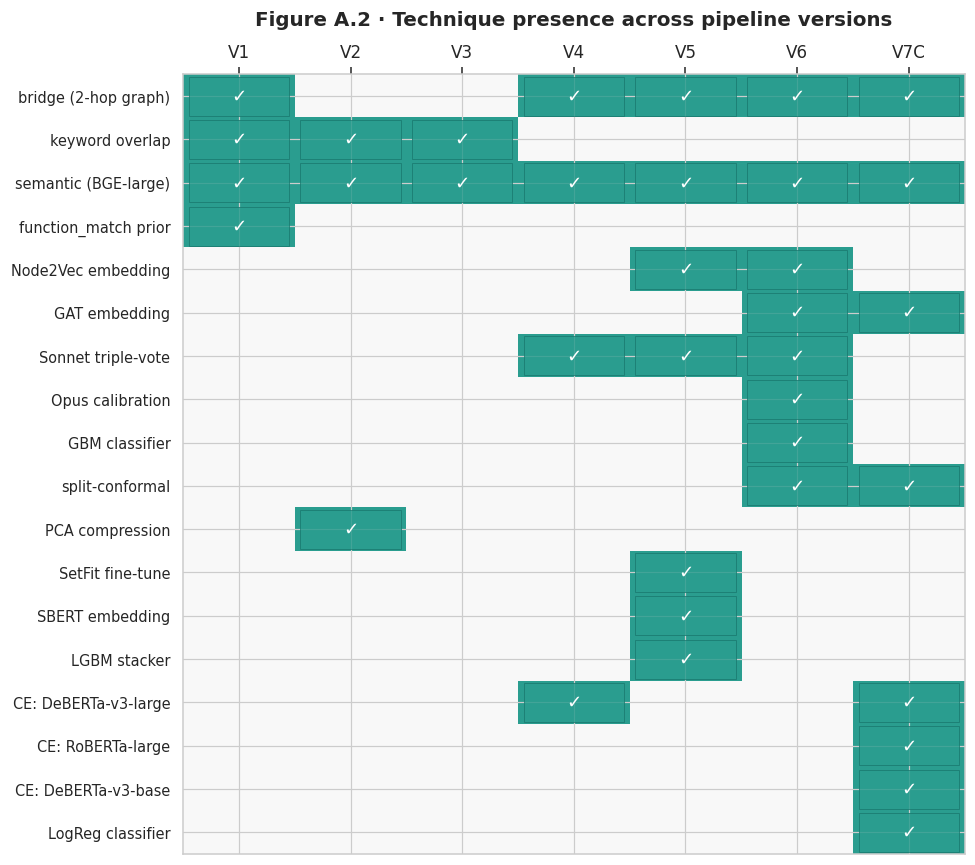

In [30]:
# Figure A.2. Technique presence matrix. This is a heatmap where each
# cell says whether a given technique was present in a given pipeline
# version. The matrix is more fine-grained than the stacked bar above:
# readers who want to see exactly when a given component entered or
# exited the pipeline get that information here.
from matplotlib.patches import Rectangle as _Rect

techniques = [
    "bridge (2-hop graph)",
    "keyword overlap",
    "semantic (BGE-large)",
    "function_match prior",
    "Node2Vec embedding",
    "GAT embedding",
    "Sonnet triple-vote",
    "Opus calibration",
    "GBM classifier",
    "split-conformal",
    "PCA compression",
    "SetFit fine-tune",
    "SBERT embedding",
    "LGBM stacker",
    "CE: DeBERTa-v3-large",
    "CE: RoBERTa-large",
    "CE: DeBERTa-v3-base",
    "LogReg classifier",
]

versions = ["v1", "v2", "v3", "v4", "v5", "v6", "v7c"]
presence = np.array([
    # v1  v2  v3  v4  v5  v6  v7c
    [ 1,  0,  0,  1,  1,  1,  1],  # bridge
    [ 1,  1,  1,  0,  0,  0,  0],  # keyword overlap
    [ 1,  1,  1,  1,  1,  1,  1],  # semantic (BGE-large)
    [ 1,  0,  0,  0,  0,  0,  0],  # function_match
    [ 0,  0,  0,  0,  1,  1,  0],  # Node2Vec
    [ 0,  0,  0,  0,  0,  1,  1],  # GAT
    [ 0,  0,  0,  1,  1,  1,  0],  # Sonnet triple-vote
    [ 0,  0,  0,  0,  0,  1,  0],  # Opus calibration
    [ 0,  0,  0,  0,  0,  1,  0],  # GBM
    [ 0,  0,  0,  0,  0,  1,  1],  # split-conformal
    [ 0,  1,  0,  0,  0,  0,  0],  # PCA
    [ 0,  0,  0,  0,  1,  0,  0],  # SetFit
    [ 0,  0,  0,  0,  1,  0,  0],  # SBERT
    [ 0,  0,  0,  0,  1,  0,  0],  # LGBM
    [ 0,  0,  0,  1,  0,  0,  1],  # CE: DeBERTa-v3-large
    [ 0,  0,  0,  0,  0,  0,  1],  # CE: RoBERTa-large
    [ 0,  0,  0,  0,  0,  0,  1],  # CE: DeBERTa-v3-base
    [ 0,  0,  0,  0,  0,  0,  1],  # LogReg
])

fig, ax = plt.subplots(figsize=(9, 8))
cmap = plt.cm.colors.ListedColormap(["#f8f8f8", "#2a9d8f"])
ax.imshow(presence, cmap=cmap, aspect="auto", interpolation="none")

for i in range(presence.shape[0]):
    for j in range(presence.shape[1]):
        if presence[i, j]:
            ax.add_patch(_Rect((j - 0.45, i - 0.45), 0.9, 0.9,
                               linewidth=0.6, edgecolor="#1a7a70",
                               facecolor="#2a9d8f", alpha=0.85))
            ax.text(j, i, "\u2713", ha="center", va="center",
                    fontsize=12, color="white", fontweight="bold")

ax.set_xticks(range(len(versions)))
ax.set_xticklabels([v.upper() for v in versions], fontsize=11)
ax.set_yticks(range(len(techniques)))
ax.set_yticklabels(techniques, fontsize=9.5)
ax.set_title("Figure A.2 · Technique presence across pipeline versions",
             fontsize=13, fontweight="bold", pad=12)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
plt.tight_layout()
plt.show()

### Per-iteration retrospective

**v1. Four-signal composite.** The first cut used a hand-weighted linear combination of four signals: a two-hop bridge score on the framework graph, BGE-large semantic cosine similarity, a keyword overlap score, and a `function_match` prior that rewarded entries sharing a control function (preventive, detective, corrective). I picked weights of roughly 0.47 / 0.33 / 0.20 / bonus by eyeballing a small validation set. It worked well enough to demo but not well enough to ship: when I diffed v1 against the first v2 expert-crosswalk rerun I found that only 57 of 119 (47.9%) of v1 expert edges were preserved, and 62 were lost. That regression number is what convinced me to move off hand-tuned weights. *Learned:* hand weights feel principled until you measure them against a real label set. After that they feel arbitrary.

**v2. Multi-encoder stacker + PCA.** I added a second encoder, stacked it against the v1 signals, and ran PCA to compress the joint feature space before the classifier. Two-stage sacred evaluation exposed a majority-class collapse: the classifier was predicting 'Related' on almost every pair. The root cause was that PCA preserved the directions of largest variance but threw away the direction that separated the rare tiers. *Learned:* when the task is imbalanced class separation, PCA is not free dimensionality reduction; it can remove the signal you actually need.

**v3. Human-label domain adaptation.** I rewrote the feature pipeline around raw embeddings plus a random-forest calibrator trained on the newly labeled 150-pair human calibration split. Label shift correction was added to account for the fact that the test distribution has more unrelated pairs than the cal distribution. The pipeline stabilised around a 0.40 accuracy ceiling that I could not break through with text features alone. *Learned:* text-only features plateau on this task because many cross-framework pairs are conceptually related through structure that never appears verbatim in either description.

**v4. LLM-as-judge + cross-encoder ensemble.** Rather than keep squeezing more signal out of embeddings, I introduced a Claude Sonnet triple-vote judge: for each candidate pair I prompted Claude three times with different orderings and took the modal tier. I also added a cross-encoder ensemble (DeBERTa / ELECTRA / RoBERTa fine-tuned on the cal split) and graph features from a Node2Vec embedding. The RF calibrator consumed all of these. Frozen-test accuracy jumped to 0.468, the first real lift since v1. The ablation showed the LLM judge carried most of that lift; the cross-encoder ensemble added less than a percentage point. *Learned:* the LLM judge is the single most productive feature source on this task, and once it is in the stack the cross-encoder ensemble is expensive noise.

**v5. SBERT + LGBM stacker + SetFit + hierarchical LLM.** I replaced the RF calibrator with an LGBM stacker and added three more signal sources: SBERT sentence embeddings, a SetFit fine-tuned projection trained on the 150-pair cal split, and a hierarchical LLM prompt that asked Claude to first decide related-vs-unrelated and then decide the exact tier. Feature count hit 38. Frozen-test accuracy climbed to 0.505 but macro F1 flattened, and a mid-cycle experiment with a GAT + Mondrian-conformal variant collapsed to majority-class (tier accuracy 0.373) and tripped the break-glass gate. That was the moment I decided the pipeline was too wide. *Learned:* past a certain feature count, more features stops helping and starts hurting, and adding exotic components (GAT, SetFit, hierarchical prompts) made the pipeline harder to debug without proportional accuracy gain.

**v6. Reframed 22d GBM + split-conformal.** For v6 I threw out everything that did not earn its place: SBERT, SetFit, cross-encoder, LGBM stacker, PCA, hierarchical prompts, and the router features. The survivors are seven LLM features (the Sonnet triple-vote scores plus derived statistics), 13 structural features (graph depth, description length, Node2Vec cosine, GAT cosine, and four binary entry-type flags), and two Opus calibration features. 22 features total. The classifier is a single `GradientBoostingClassifier`; there is no stacker, no ensemble, no reranker. On top of that I wrapped the classifier in a split-conformal prediction procedure at α = 0.10 so every prediction ships with a calibrated set instead of a point estimate. Frozen tier accuracy is 0.5325, macro F1 is 0.489, adjacent accuracy is 0.84, and conformal coverage is 0.94, above the 0.90 nominal guarantee. *Learned:* pruning features is as important as adding them, and adding an honest uncertainty layer lets me ship a classifier whose mistakes I can at least predict.

**v7c. 3-model CE ensemble + GAT + LogReg.** The seventh iteration replaced the LLM triple-vote and Opus calibration features with cross-encoder soft probabilities from three transformer models (DeBERTa-v3-large, RoBERTa-large, DeBERTa-v3-base). Each model emits a 4-class probability vector per pair, yielding 12 CE features. Combined with 35 GAT features and 3 baseline features, the total feature count rose to 50. The classifier switched from GBM to regularized LogReg (C=0.01, selected by CV). The result was the largest accuracy jump in the series: 53.3% to 81.0% on the frozen test set. RoBERTa-large dominates feature importance, contributing the top four features by weight. Conformal coverage is 91.6% with an average set size of 1.56, a substantial improvement over v6's conformal behavior. The main remaining gap is the Equivalent tier (F1=0.0), limited by the 7-pair test sample.

> **Plain English:** Over seven rewrites the classifier went from a hand-tuned scoring formula to a 50-feature logistic regression powered by three cross-encoder transformer models. The biggest single lift came from swapping LLM-as-judge features for cross-encoder soft probabilities at v7c. The biggest single lesson came from v5 and v6, where adding noisy features stopped helping, and v7c worked better because it added high-quality features (transformer class probabilities) instead of noisy ones.